In [1]:
!pip install fiona
!pip install geopy

import pandas as pd
import geopandas as gpd
import fiona as fiona
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from geopy.distance import distance
from geopy.distance import geodesic
from shapely.geometry import Polygon, Point
from sklearn.metrics import pairwise_distances
from math import ceil



In [3]:
# Load the shapefile using geopandas
shapefile_path = 'Shapefiles/zmb_admbnda_adm2_dmmu_20201124.shp'  
adm2_region = gpd.read_file(shapefile_path)
sinazongwe_region = adm2_region[adm2_region['ADM2_EN']=='Sinazongwe']

In [4]:
orphanhood_prev_hh = pd.read_csv('orphanhood_prev_hh')

In [5]:
orphanhood_prev_hh

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM
0,1,-15.412262,28.218528,33.333333,0.000000,0.000000,33.333333,1,0,0,1,3,-15.412262,28.218528
1,2,-15.414888,28.277888,100.000000,100.000000,100.000000,100.000000,1,1,1,1,1,-15.414888,28.277888
2,3,-15.421163,28.246461,100.000000,0.000000,0.000000,100.000000,1,0,0,1,1,-15.421163,28.246461
3,4,-15.421221,28.234018,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-15.421221,28.234018
4,5,-16.964455,27.637396,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-16.964455,27.637396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3820,3821,-17.860621,27.026514,33.333333,33.333333,33.333333,33.333333,1,1,1,1,3,-17.860621,27.026514
3821,3822,-17.861259,27.021785,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861259,27.021785
3822,3823,-17.861279,27.021786,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861279,27.021786
3823,3824,-17.861289,27.021780,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861289,27.021780


In [6]:
coords = np.radians(orphanhood_prev_hh[['lat', 'long']].to_numpy())

# Perform DBSCAN with prebuilt haversine metric
kms_per_radian = 6371.0088  # Earth's radius
epsilon = 4 / kms_per_radian  # 5 km radius

db = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine')
clusters = db.fit_predict(coords)


In [7]:
coords

array([[-0.26899472,  0.49250622],
       [-0.26904055,  0.49354226],
       [-0.26915006,  0.49299375],
       ...,
       [-0.31173813,  0.47161914],
       [-0.31173829,  0.47161904],
       [-0.31173847,  0.47161721]])

In [8]:
# Add cluster labels to the dataframe
orphanhood_prev_hh['cluster'] = clusters

In [9]:
# Find cluster centers
cluster_centers = []
for cluster_id in set(clusters):
    if cluster_id != -1:  # Exclude noise points
        cluster_points = orphanhood_prev_hh[orphanhood_prev_hh['cluster'] == cluster_id][['lat', 'long']]
        center_lat = cluster_points['lat'].mean()
        center_lon = cluster_points['long'].mean()
        cluster_centers.append({'cluster': cluster_id, 'center_lat': center_lat, 'center_lon': center_lon})

cluster_centers_df = pd.DataFrame(cluster_centers)

print("Cluster centers:")
print(cluster_centers_df)

Cluster centers:
   cluster  center_lat  center_lon
0        0  -17.011779   27.649712
1        1  -17.074661   27.532732
2        2  -17.218071   27.466687
3        3  -17.345093   27.407323
4        4  -17.418065   27.249352
5        5  -17.684293   27.029169
6        6  -17.723645   26.930540
7        7  -17.821056   27.063589


In [10]:
def geodesic_cluster_distances(center, points):
    return [geodesic((center['center_lat'], center['center_lon']), (lat, lon)).meters for lat, lon in zip(points['lat'], points['long'])]

In [11]:
# Find minimum radius for each cluster

min_radii = []

for center in cluster_centers:
    center_lat = center['center_lat']
    center_lon = center['center_lon']
    cluster_label = center['cluster']

    cluster_points = orphanhood_prev_hh[orphanhood_prev_hh['cluster'] == cluster_label][['lat', 'long']]

    # Calculate geodesic distances
    distances = geodesic_cluster_distances(center, cluster_points)
    min_radius = max(distances)
    min_radii.append({'cluster_label': cluster_label, 'min_radius': min_radius})

min_radius_dict = {item['cluster_label']: item['min_radius'] for item in min_radii}

min_radius_dict


{np.int64(0): 7599.7470578241555,
 np.int64(1): 9815.660461163263,
 np.int64(2): 11313.660161743179,
 np.int64(3): 844.4248390435698,
 np.int64(4): 18475.531921355025,
 np.int64(5): 7120.692569936751,
 np.int64(6): 2518.7024300573016,
 np.int64(7): 6503.327891474927}

In [12]:
ceil(min_radius_dict[5])

7121

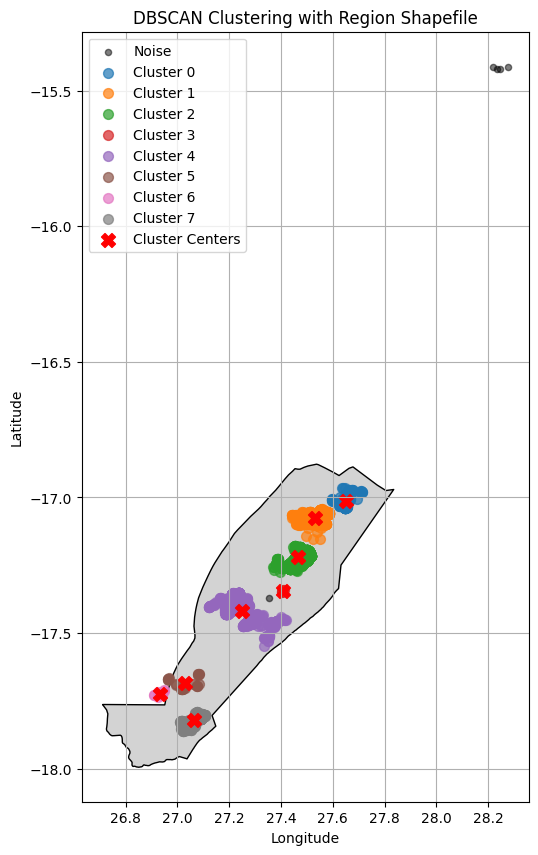

In [13]:
# Step 6: Plot the results
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the shapefile (region boundary)
sinazongwe_region.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot the cluster points
for cluster_id in orphanhood_prev_hh['cluster'].unique():
    cluster_points = orphanhood_prev_hh[orphanhood_prev_hh['cluster'] == cluster_id]
    if cluster_id == -1:  # Noise points
        plt.scatter(cluster_points['long'], cluster_points['lat'], 
                    color='black', label='Noise', s=20, alpha=0.5)
    else:
        plt.scatter(cluster_points['long'], cluster_points['lat'], 
                    label=f'Cluster {cluster_id}', s=50, alpha=0.7)

# Plot cluster centers
plt.scatter(cluster_centers_df['center_lon'], cluster_centers_df['center_lat'], 
            color='red', label='Cluster Centers', s=100, marker='X')

# Add titles and labels
plt.title("DBSCAN Clustering with Region Shapefile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [14]:
orphanhood_prev_hh

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM,cluster
0,1,-15.412262,28.218528,33.333333,0.000000,0.000000,33.333333,1,0,0,1,3,-15.412262,28.218528,-1
1,2,-15.414888,28.277888,100.000000,100.000000,100.000000,100.000000,1,1,1,1,1,-15.414888,28.277888,-1
2,3,-15.421163,28.246461,100.000000,0.000000,0.000000,100.000000,1,0,0,1,1,-15.421163,28.246461,-1
3,4,-15.421221,28.234018,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-15.421221,28.234018,-1
4,5,-16.964455,27.637396,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-16.964455,27.637396,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3820,3821,-17.860621,27.026514,33.333333,33.333333,33.333333,33.333333,1,1,1,1,3,-17.860621,27.026514,7
3821,3822,-17.861259,27.021785,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861259,27.021785,7
3822,3823,-17.861279,27.021786,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861279,27.021786,7
3823,3824,-17.861289,27.021780,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861289,27.021780,7


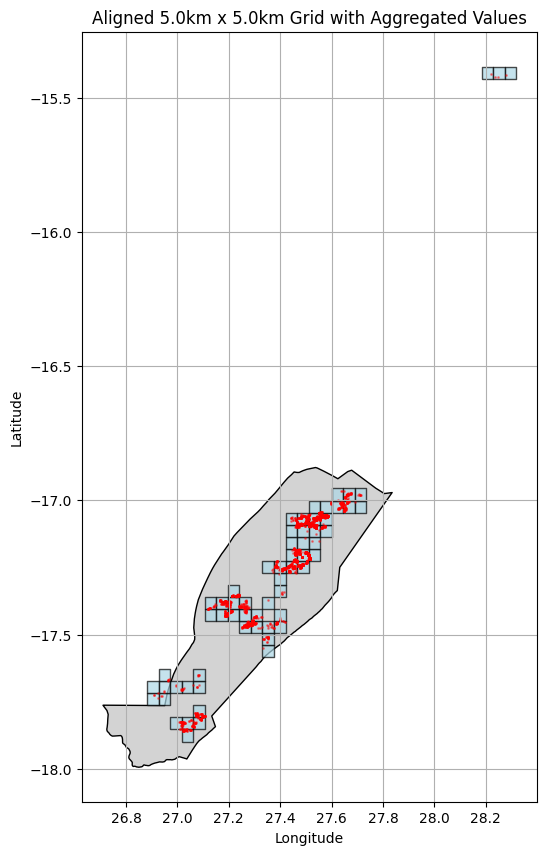

In [ ]:
# Step 1: DataFrame with location coordinates

df = pd.read_csv('orphanhood_prev_hh')

# Step 2: Set grid size (in meters) and calculate degrees
pixel_size_meters = 5000  # Desired grid size
deg_per_meter = 1 / 111320  # Approximate degrees per meter (at equator)

grid_spacing_deg = pixel_size_meters * deg_per_meter  # Convert grid size to degrees

# Step 3: Snap coordinates to the grid
def snap_to_grid(lat, lon, grid_spacing):
    snapped_lat = np.round(lat / grid_spacing) * grid_spacing
    snapped_lon = np.round(lon / grid_spacing) * grid_spacing
    return snapped_lat, snapped_lon

# Apply snapping to grid
df[['latitude_snapped', 'longitude_snapped']] = df.apply(
    lambda row: pd.Series(snap_to_grid(row['lat'], row['long'], grid_spacing_deg)),
    axis=1
)

# Step 4: Group by snapped coordinates and aggregate values
aggregated_df_og = df.groupby(['latitude_snapped', 'longitude_snapped'], as_index=False).agg({
    'total_children': 'sum',
    'mat_total': 'sum',
    'pat_total': 'sum',
    'both_total': 'sum',
    'atleast1_total': 'sum'
})

# Step 5: Create adjacent square polygons based on snapped coordinates
def create_square(lat, lon, grid_spacing):
    """Create a square polygon centered at (lat, lon)."""
    half_spacing = grid_spacing / 2
    bottom_left = (lon - half_spacing, lat - half_spacing)
    bottom_right = (lon + half_spacing, lat - half_spacing)
    top_right = (lon + half_spacing, lat + half_spacing)
    top_left = (lon - half_spacing, lat + half_spacing)
    return Polygon([bottom_left, bottom_right, top_right, top_left, bottom_left])

# Generate polygons for each grid center
aggregated_df_og['geometry'] = aggregated_df_og.apply(
    lambda row: create_square(row['latitude_snapped'], row['longitude_snapped'], grid_spacing_deg),
    axis=1
)

# Step 6: Create a GeoDataFrame
gdf = gpd.GeoDataFrame(aggregated_df_og, geometry='geometry', crs="EPSG:4326")

# Step 7: Plot the grid with aggregated values
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the shapefile (region boundary)
sinazongwe_region.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot polygons
gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7)


# Plot the centroids (original points)
gdf_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df['long'], df['lat']), crs="EPSG:4326")
gdf_points.plot(ax=ax, color='red', markersize=1, alpha=0.4, label='Centroids')


# Final touches
plt.title(f"Aligned {pixel_size_meters/1000}km x {pixel_size_meters/1000}km Grid with Aggregated Values")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()

In [16]:
aggregated_df_og

,latitude_snapped,longitude_snapped,total_children,mat_total,pat_total,both_total,atleast1_total,geometry
0,-17.876392,27.039166,30,1,1,1,1,POLYGON ((27.016708587854833 -17.8988501616960...
1,-17.831477,26.994251,19,1,4,0,5,POLYGON ((26.97179302910528 -17.85393460294646...
2,-17.831477,27.039166,74,6,3,0,9,POLYGON ((27.016708587854833 -17.8539346029464...
3,-17.831477,27.084082,85,0,3,0,3,POLYGON ((27.061624146604384 -17.8539346029464...
4,-17.786561,27.084082,132,0,1,0,1,POLYGON ((27.061624146604384 -17.8090190441969...
...,...,...,...,...,...,...,...,...
58,-16.978081,27.667984,69,16,30,5,41,POLYGON ((27.645526410348545 -17.0005389867049...
59,-16.978081,27.712900,8,7,3,2,8,POLYGON ((27.690441969098096 -17.0005389867049...
60,-15.406037,28.206971,3,1,0,0,1,POLYGON ((28.184513115343155 -15.4284944304707...
61,-15.406037,28.251886,2,1,0,0,1,POLYGON ((28.229428674092706 -15.4284944304707...


In [44]:
# -*- coding: utf-8 -*-
"""
Rectangular patches covering points with constraints:
- each side length >= 2 km
- min area >= 25 km²
- total (summed) rectangle area <= 340 km²
Uses KMeans clustering (one rectangle per cluster) and picks the best feasible K.
"""

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.prepared import prep
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Configuration
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"   # change if needed
LAT_COL = "lat"
LON_COL = "long"

# Optional boundary to plot (set to None to skip)
BOUNDARY_PATH = None  # e.g., "sinazongwe_region.shp"

# Rectangle constraints
MIN_SIDE_M = 2000          # each side >= 2 km
MIN_AREA_KM2 = 25
AREA_CAP_KM2 = 340

# With 25 km² minimum per rectangle, at most 13 rectangles (13*25 = 325 <= 340)
K_MAX_CAP = 13

# Optional save path
SAVE_GEOJSON = "rectangles_min25km2.geojson"  # set to None to skip saving


# -----------------------------
# Helpers
# -----------------------------
def guess_utm_epsg(lon, lat):
    """Guess UTM EPSG from lon/lat (WGS84)."""
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone


def build_rectangles(X_m, labels, min_side_m=MIN_SIDE_M, min_area_km2=MIN_AREA_KM2):
    """
    For each cluster label:
      - take bbox of points,
      - enforce side lengths >= min_side_m,
      - if area < min_area, enlarge ONLY ONE side (width or height) just enough to reach min area.
    Returns list of shapely boxes (in meters CRS).
    """
    min_area_m2 = min_area_km2 * 1_000_000
    rects = []
    for k in np.unique(labels):
        pts = X_m[labels == k]
        minx, miny = pts.min(axis=0)
        maxx, maxy = pts.max(axis=0)
        cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0

        # Half-spans to cover points and meet min side
        half_w = max((maxx - minx) / 2.0, min_side_m / 2.0)
        half_h = max((maxy - miny) / 2.0, min_side_m / 2.0)

        width = 2 * half_w
        height = 2 * half_h
        area = width * height

        if area < min_area_m2:
            # Option A: increase width only
            cand_width = max(width, min_area_m2 / height)
            # Option B: increase height only
            cand_height = max(height, min_area_m2 / width)
            # Choose the smaller change
            if (cand_width - width) <= (cand_height - height):
                half_w = cand_width / 2.0
            else:
                half_h = cand_height / 2.0

        rects.append(box(cx - half_w, cy - half_h, cx + half_w, cy + half_h))
    return rects


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must contain '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326",
)

# Optional boundary
boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

# -----------------------------
# Project to a local meters CRS (UTM)
# -----------------------------
centroid = gdf_pts.geometry.union_all().centroid  # no deprecation warning
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)

gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)
X = np.vstack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values]).T
n = len(X)
if n == 0:
    raise ValueError("No points to cover.")

# -----------------------------
# Search over K and pick best feasible (min summed area ≤ cap)
# -----------------------------
K_max = min(K_MAX_CAP, n)
best = None

for K in range(1, K_max + 1):
    km = KMeans(n_clusters=K, n_init=25, random_state=42)
    labels = km.fit_predict(X)
    rects = build_rectangles(X, labels)
    total_area_m2 = sum(r.area for r in rects)
    print(f"K={K}, total summed area = {total_area_m2/1_000_000:.2f} km²")

    if total_area_m2 <= AREA_CAP_KM2 * 1_000_000:
        if best is None or total_area_m2 < best["total_area_m2"]:
            best = {"K": K, "rects": rects, "total_area_m2": total_area_m2}

if best is None:
    raise RuntimeError(
        "No feasible set of rectangles meeting: "
        f"each side ≥ {MIN_SIDE_M/1000:.0f} km, min area {MIN_AREA_KM2} km², "
        f"and total summed area ≤ {AREA_CAP_KM2} km²."
    )

# -----------------------------
# Outputs (meters + WGS84), union area info
# -----------------------------
rects_gdf_m = gpd.GeoDataFrame(
    {"cluster": list(range(best["K"]))},
    geometry=best["rects"],
    crs=gdf_pts_m.crs,
)
rects_gdf = rects_gdf_m.to_crs(epsg=4326)

# Union area (no double counting) for reference
union_m = gpd.GeoSeries(best["rects"], crs=gdf_pts_m.crs).union_all()
true_union_area_km2 = union_m.area / 1_000_000

print(f"Chosen K = {best['K']}")
print(f"Total summed area = {best['total_area_m2']/1_000_000:.2f} km² (cap {AREA_CAP_KM2} km²)")
print(f"True covered area (union) = {true_union_area_km2:.2f} km²")
print(f"Min side length enforced: {MIN_SIDE_M/1000:.0f} km; min area: {MIN_AREA_KM2} km²")

# Sanity check: all points covered by union
prep_union = prep(union_m)
covered = [prep_union.contains(pt) or prep_union.touches(pt) for pt in gdf_pts_m.geometry]
if not all(covered):
    print(f"WARNING: {len(covered) - sum(covered)} points are not inside/touching the union.")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

if boundary is not None:
    boundary.plot(ax=ax, color="lightgrey", edgecolor="black")

rects_gdf.boundary.plot(ax=ax, linewidth=1.2, color="black")
rects_gdf.plot(ax=ax, alpha=0.25, edgecolor="black")

gdf_pts.plot(ax=ax, color="red", markersize=4, alpha=0.6)

plt.title(
    f"Rectangular patches (side≥{MIN_SIDE_M/1000:.0f} km, area≥{MIN_AREA_KM2} km²)\n"
    f"K={best['K']}, Summed area={best['total_area_m2']/1_000_000:.2f} km² (cap {AREA_CAP_KM2}); "
    f"Union={true_union_area_km2:.2f} km²"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None:
    handles.append(mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="lightblue", edgecolor="black", label="Rectangles"))
handles.append(mpatches.Patch(facecolor="red", label="Locations"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

# -----------------------------
# Save (optional)
# -----------------------------
if SAVE_GEOJSON:
    rects_gdf.to_file(SAVE_GEOJSON, driver="GeoJSON")
    print(f"Saved rectangles to {SAVE_GEOJSON}")



K=1, total summed area = 39720.05 km²
K=2, total summed area = 24011.03 km²
K=3, total summed area = 21570.62 km²
K=4, total summed area = 18891.85 km²
K=5, total summed area = 2185.30 km²
K=6, total summed area = 1796.75 km²
K=7, total summed area = 1596.21 km²
K=8, total summed area = 1581.46 km²
K=9, total summed area = 1480.74 km²
K=10, total summed area = 1246.70 km²
K=11, total summed area = 1216.80 km²
K=12, total summed area = 1168.14 km²
K=13, total summed area = 1092.00 km²


RuntimeError: No feasible set of rectangles meeting: each side ≥ 2 km, min area 25 km², and total summed area ≤ 340 km².

In [45]:
# -*- coding: utf-8 -*-
"""
Greedy rectangle cover without K-Means:
- each rectangle side >= 2 km
- each rectangle area >= 25 km²
- minimize total summed area; succeed if total <= 340 km²
Strategy:
  1) Project to UTM (meters).
  2) Snap points to a 2 km grid -> initial clusters (dramatically reduces count).
  3) Define rectangle-for-cluster with constraints (min side, min area, expand one side only if needed).
  4) Greedy agglomerative merging: repeatedly merge the pair that yields the smallest increase in total area,
     until number of clusters <= 13 (theoretical max under 340/25).
  5) If total summed area <= 340 km² -> feasible. Report rectangles and plot.
"""

import os
import math
import heapq
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.prepared import prep
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Configuration
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"   # change if needed
LAT_COL = "lat"
LON_COL = "long"

# Optional boundary file to plot (set to None to skip)
BOUNDARY_PATH = None  # e.g., "sinazongwe_region.shp"

# Constraints
MIN_SIDE_M = 2000           # each side >= 2 km
MIN_AREA_KM2 = 25
AREA_CAP_KM2 = 340
MAX_RECTANGLES = int(AREA_CAP_KM2 // MIN_AREA_KM2)  # 13 if 340/25

# Grid for initial grouping (meters) – 2 km matches min side requirement
SNAP_GRID_M = 2000

# Output (optional)
SAVE_GEOJSON = "rectangles_greedy_no_kmeans.geojson"  # set to None to skip


# -----------------------------
# Helpers
# -----------------------------
def guess_utm_epsg(lon, lat):
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def rect_from_points(xy_array, min_side_m=MIN_SIDE_M, min_area_km2=MIN_AREA_KM2):
    """
    Build an axis-aligned rectangle covering all points in xy_array (meters),
    with side lengths >= min_side_m, and area >= min_area_km2.
    If area < min_area, enlarge ONLY ONE side (width or height) just enough to reach min area.
    Returns (poly, width, height, area_m2, center_x, center_y).
    """
    min_area_m2 = min_area_km2 * 1_000_000
    xs = xy_array[:, 0]; ys = xy_array[:, 1]
    minx, maxx = xs.min(), xs.max()
    miny, maxy = ys.min(), ys.max()
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0

    half_w = max((maxx - minx) / 2.0, min_side_m / 2.0)
    half_h = max((maxy - miny) / 2.0, min_side_m / 2.0)

    width = 2 * half_w
    height = 2 * half_h
    area = width * height

    if area < min_area_m2:
        cand_width = max(width, min_area_m2 / height)
        cand_height = max(height, min_area_m2 / width)
        if (cand_width - width) <= (cand_height - height):
            width = cand_width
            half_w = width / 2.0
        else:
            height = cand_height
            half_h = height / 2.0
        area = width * height

    poly = box(cx - half_w, cy - half_h, cx + half_w, cy + half_h)
    return poly, width, height, area, cx, cy

def cluster_area(xy_array):
    """Return area_m2 of rectangle covering given points with constraints."""
    return rect_from_points(xy_array)[3]

def merged_area(a_xy, b_xy):
    """Area of rectangle for union of two clusters' points."""
    merged = np.vstack([a_xy, b_xy])
    return cluster_area(merged)

# -----------------------------
# Load + project to meters
# -----------------------------
df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must contain '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326",
)

boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)
gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)

coords = np.vstack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values]).T
n = len(coords)
if n == 0:
    raise ValueError("No points to cover.")

# -----------------------------
# Initial clusters via 2 km snapping
# -----------------------------
# Snap each point to a 2 km grid cell; points sharing a cell start as one cluster
ix = np.floor_divide((coords[:, 0]).astype(np.int64), SNAP_GRID_M)
iy = np.floor_divide((coords[:, 1]).astype(np.int64), SNAP_GRID_M)
grid_keys = pd.Series(list(zip(ix, iy)))

clusters = {}
for k, idxs in grid_keys.groupby(grid_keys).groups.items():
    clusters[len(clusters)] = coords[np.array(list(idxs))]

# If still too many clusters, this is fine; merging will reduce them.
print(f"Initial clusters: {len(clusters)} (from {n} points)")

# Pre-compute current rectangles and areas
rect_info = {}  # id -> (poly, area_m2)
for cid, pts in clusters.items():
    poly, w, h, area, cx, cy = rect_from_points(pts)
    rect_info[cid] = (poly, area)

def total_area():
    return sum(a for _, a in rect_info.values())

# -----------------------------
# Build a priority queue of pairwise merge costs (delta area)
# -----------------------------
def pair_delta(cid1, cid2):
    a_xy = clusters[cid1]; b_xy = clusters[cid2]
    a_area = rect_info[cid1][1]; b_area = rect_info[cid2][1]
    m_area = merged_area(a_xy, b_xy)
    return m_area - (a_area + b_area)

# Use a heap of (delta, cid1, cid2). Rebuild lazily when needed.
def build_heap(active_ids):
    active_ids = list(active_ids)
    heap = []
    for i in range(len(active_ids)):
        for j in range(i+1, len(active_ids)):
            c1, c2 = active_ids[i], active_ids[j]
            d = pair_delta(c1, c2)
            heapq.heappush(heap, (d, c1, c2))
    return heap

active = set(clusters.keys())
heap = build_heap(active)

# -----------------------------
# Greedy merging loop
# -----------------------------
while len(active) > MAX_RECTANGLES:
    if not heap:
        break  # no pairs to merge (shouldn't happen), exit

    d, c1, c2 = heapq.heappop(heap)

    # Skip invalidated pairs (clusters already merged)
    if c1 not in active or c2 not in active:
        continue

    # Merge c2 into c1 (new id = c1)
    merged_pts = np.vstack([clusters[c1], clusters[c2]])
    clusters[c1] = merged_pts
    del clusters[c2]

    # Update rect info
    poly, w, h, area, cx, cy = rect_from_points(merged_pts)
    rect_info[c1] = (poly, area)
    del rect_info[c2]

    # Update active set
    active.remove(c2)

    # Rebuild heap entries that involve c1 (lazy approach: push new pairs for c1; old stale pairs are skipped later)
    for other in list(active):
        if other == c1:
            continue
        d_new = pair_delta(c1, other)
        heapq.heappush(heap, (d_new, c1, other))

# -----------------------------
# Evaluate feasibility
# -----------------------------
summed_area_km2 = total_area() / 1_000_000
print(f"Clusters after merging: {len(active)}")
print(f"Total summed area = {summed_area_km2:.2f} km² (cap {AREA_CAP_KM2} km²)")

if summed_area_km2 > AREA_CAP_KM2:
    raise RuntimeError(
        f"Not feasible under constraints: need {summed_area_km2:.2f} km² > {AREA_CAP_KM2} km² "
        f"with {len(active)} rectangles (min side 2 km, min area 25 km²)."
    )

# -----------------------------
# Build GeoDataFrame of rectangles (WGS84) and union area
# -----------------------------
rects_m = []
for cid in active:
    poly = rect_info[cid][0]
    rects_m.append(poly)

rects_gdf_m = gpd.GeoDataFrame(
    {"cluster": list(range(len(rects_m)))},
    geometry=rects_m,
    crs=gdf_pts_m.crs,
)
rects_gdf = rects_gdf_m.to_crs(epsg=4326)

# Union area (for info, no double-counting)
union_m = gpd.GeoSeries(rects_m, crs=gdf_pts_m.crs).union_all()
union_area_km2 = union_m.area / 1_000_000
print(f"True covered area (union, no double counting) = {union_area_km2:.2f} km²")

# Coverage check
prep_union = prep(union_m)
covered = [prep_union.contains(pt) or prep_union.touches(pt) for pt in gdf_pts_m.geometry]
if not all(covered):
    print(f"WARNING: {len(covered) - sum(covered)} points are not inside/touching the union of rectangles.")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

if boundary is not None:
    boundary.plot(ax=ax, color="lightgrey", edgecolor="black")

rects_gdf.boundary.plot(ax=ax, linewidth=1.2, color="black")
rects_gdf.plot(ax=ax, alpha=0.25, edgecolor="black")

gdf_pts.plot(ax=ax, color="red", markersize=3, alpha=0.6)

plt.title(
    f"Greedy cover (no K-Means): side≥{MIN_SIDE_M/1000:.0f} km, area≥{MIN_AREA_KM2} km²\n"
    f"{len(active)} rectangles; summed area={summed_area_km2:.2f} km² (cap {AREA_CAP_KM2}); "
    f"union={union_area_km2:.2f} km²"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None:
    handles.append(mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="lightblue", edgecolor="black", label="Rectangles"))
handles.append(mpatches.Patch(facecolor="red", label="Locations"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

# -----------------------------
# Save (optional)
# -----------------------------
if SAVE_GEOJSON:
    rects_gdf.to_file(SAVE_GEOJSON, driver="GeoJSON")
    print(f"Saved rectangles to {SAVE_GEOJSON}")


Initial clusters: 165 (from 3825 points)
Clusters after merging: 13
Total summed area = 1303.10 km² (cap 340 km²)


RuntimeError: Not feasible under constraints: need 1303.10 km² > 340 km² with 13 rectangles (min side 2 km, min area 25 km²).

In [47]:
# -*- coding: utf-8 -*-
"""
Multi-start GREEDY rectangle cover (no K-Means):
- each rectangle side >= 2 km
- each rectangle area >= 25 km² (expand one side only if needed)
- total (summed) area <= 340 km²
- search by running the greedy algorithm multiple times with random 2 km grid offsets;
  keep the best feasible solution, if any.

Requires: numpy, pandas, geopandas, shapely, matplotlib
"""

import os
import math
import random
import heapq
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.prepared import prep
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Configuration
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"   # change if needed
LAT_COL = "lat"
LON_COL = "long"

# Optional boundary file to plot (set to None to skip)
BOUNDARY_PATH = None  # e.g., "sinazongwe_region.shp" or "boundary.gpkg"

# Constraints
MIN_SIDE_M = 2000           # each side >= 2 km
MIN_AREA_KM2 = 25
AREA_CAP_KM2 = 340
MAX_RECTANGLES = int(AREA_CAP_KM2 // MIN_AREA_KM2)  # 13 if 340/25

# Initial snapping grid (meters). 2 km matches the minimum side.
SNAP_GRID_M = 2000

# Multi-start settings
RANDOM_RESTARTS = 40               # increase to search harder (e.g. 200)
RANDOM_SEED = 42                   # set None for fully random
VERBOSE = True

# Output (optional)
SAVE_GEOJSON_BEST = "rectangles_greedy_multistart.geojson"  # set to None to skip saving


# -----------------------------
# Helpers
# -----------------------------
def guess_utm_epsg(lon, lat):
    """Guess UTM EPSG code from lon/lat (WGS84)."""
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def rect_from_points(xy_array, min_side_m=MIN_SIDE_M, min_area_km2=MIN_AREA_KM2):
    """
    Build an axis-aligned rectangle covering all points in xy_array (meters),
    with side lengths >= min_side_m, and area >= min_area_km2.
    If area < min_area, enlarge ONLY ONE side (width or height) just enough
    to reach min area. Returns (poly, width, height, area_m2, center_x, center_y).
    """
    min_area_m2 = min_area_km2 * 1_000_000
    xs = xy_array[:, 0]; ys = xy_array[:, 1]
    minx, maxx = xs.min(), xs.max()
    miny, maxy = ys.min(), ys.max()
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0

    half_w = max((maxx - minx) / 2.0, min_side_m / 2.0)
    half_h = max((maxy - miny) / 2.0, min_side_m / 2.0)

    width = 2 * half_w
    height = 2 * half_h
    area = width * height

    if area < min_area_m2:
        # Option A: increase width only
        cand_width = max(width, min_area_m2 / height)
        # Option B: increase height only
        cand_height = max(height, min_area_m2 / width)
        # Choose the smaller change
        if (cand_width - width) <= (cand_height - height):
            width = cand_width
            half_w = width / 2.0
        else:
            height = cand_height
            half_h = height / 2.0
        area = width * height

    poly = box(cx - half_w, cy - half_h, cx + half_w, cy + half_h)
    return poly, width, height, area, cx, cy

def cluster_area(xy_array):
    """Return area (m²) of constrained rectangle covering given points."""
    return rect_from_points(xy_array)[3]

def merged_area(a_xy, b_xy):
    """Area (m²) of constrained rectangle for the union of two clusters' points."""
    merged = np.vstack([a_xy, b_xy])
    return cluster_area(merged)

def snap_with_offset(coords_m, offset_x, offset_y, snap=SNAP_GRID_M):
    """
    Snap coordinates to a grid of cell size `snap`, with origin shifted by (offset_x, offset_y).
    Returns a dict: cluster_id -> ndarray of points in that snapped cell.
    """
    ix = ((coords_m[:, 0] - offset_x) // snap).astype(np.int64)
    iy = ((coords_m[:, 1] - offset_y) // snap).astype(np.int64)
    keys = pd.Series(list(zip(ix, iy)))
    clusters = {}
    for _, idxs in keys.groupby(keys).groups.items():
        cid = len(clusters)
        clusters[cid] = coords_m[np.array(list(idxs))]
    return clusters

def greedy_merge_once(coords_m, offset_x, offset_y):
    """
    Run a single greedy solve from the given grid offset. Returns a result dict:
      {
        'summed_area_km2': float,
        'union_area_km2': float,
        'rects_gdf': GeoDataFrame (WGS84),
        'n_rects': int
      }
    or None if something went wrong internally.
    """
    # 1) initial clusters via snapping
    clusters = snap_with_offset(coords_m, offset_x, offset_y, SNAP_GRID_M)
    active = set(clusters.keys())

    # Pre-compute rectangles and areas
    rect_info = {}  # id -> (poly, area_m2)
    for cid, pts in clusters.items():
        poly, w, h, area, cx, cy = rect_from_points(pts)
        rect_info[cid] = (poly, area)

    def total_area_m2():
        return sum(a for _, a in rect_info.values())

    # Build heap of (delta, cid1, cid2)
    def pair_delta(cid1, cid2):
        a_xy = clusters[cid1]; b_xy = clusters[cid2]
        a_area = rect_info[cid1][1]; b_area = rect_info[cid2][1]
        m_area = merged_area(a_xy, b_xy)
        return m_area - (a_area + b_area)

    def build_heap(ids):
        ids = list(ids)
        heap = []
        for i in range(len(ids)):
            for j in range(i+1, len(ids)):
                c1, c2 = ids[i], ids[j]
                d = pair_delta(c1, c2)
                heapq.heappush(heap, (d, c1, c2))
        return heap

    heap = build_heap(active)

    # 2) greedy merging while > MAX_RECTANGLES
    while len(active) > MAX_RECTANGLES:
        if not heap:
            break
        d, c1, c2 = heapq.heappop(heap)
        if c1 not in active or c2 not in active:
            continue
        # Merge c2 into c1
        merged_pts = np.vstack([clusters[c1], clusters[c2]])
        clusters[c1] = merged_pts
        del clusters[c2]
        poly, w, h, area, cx, cy = rect_from_points(merged_pts)
        rect_info[c1] = (poly, area)
        del rect_info[c2]
        active.remove(c2)
        # Push fresh pairs involving c1
        for other in list(active):
            if other == c1:
                continue
            d_new = pair_delta(c1, other)
            heapq.heappush(heap, (d_new, c1, other))

    summed_area_km2 = total_area_m2() / 1_000_000

    # If still too many rectangles, we failed this run
    if len(active) > MAX_RECTANGLES:
        return None

    # Build GeoDataFrame of rects (meters CRS set later by caller)
    rects_m = [rect_info[cid][0] for cid in active]
    rects_gdf_m = gpd.GeoDataFrame(
        {"cluster": list(range(len(rects_m)))},
        geometry=rects_m,
        crs=None  # we will set CRS outside (same as points in meters)
    )

    return {
        "summed_area_km2": summed_area_km2,
        "rects_gdf_m": rects_gdf_m,
        "n_rects": len(rects_m)
    }


# -----------------------------
# Load data & project to meters
# -----------------------------
df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must contain '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326",
)

boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

# Use .union_all() to avoid deprecation warnings; get local UTM
centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)

gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)
coords_m = np.vstack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values]).T

# -----------------------------
# Multi-start loop
# -----------------------------
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

best = None
best_offset = None

for r in range(RANDOM_RESTARTS):
    # jitter offsets uniformly in [0, SNAP_GRID_M)
    ox = random.uniform(0, SNAP_GRID_M)
    oy = random.uniform(0, SNAP_GRID_M)
    res = greedy_merge_once(coords_m, ox, oy)
    if res is None:
        if VERBOSE:
            print(f"[{r+1}/{RANDOM_RESTARTS}] offset=({ox:.0f},{oy:.0f}) -> failed (too many rects)")
        continue

    # set CRS and compute union area for info
    rects_gdf_m = res["rects_gdf_m"]
    rects_gdf_m.set_crs(gdf_pts_m.crs, inplace=True)
    union_m = gpd.GeoSeries(rects_gdf_m.geometry, crs=gdf_pts_m.crs).union_all()
    union_area_km2 = union_m.area / 1_000_000

    summed_area = res["summed_area_km2"]
    n_rects = res["n_rects"]

    if VERBOSE:
        print(f"[{r+1}/{RANDOM_RESTARTS}] offset=({ox:.0f},{oy:.0f}) "
              f"-> n={n_rects}, summed={summed_area:.2f} km², union={union_area_km2:.2f} km²")

    # enforce summed area feasibility
    if summed_area <= AREA_CAP_KM2:
        # keep the best (lowest summed area) feasible solution
        if (best is None) or (summed_area < best["summed_area_km2"]):
            rects_wgs84 = rects_gdf_m.to_crs(epsg=4326)
            best = {
                "summed_area_km2": summed_area,
                "union_area_km2": union_area_km2,
                "rects_gdf_m": rects_gdf_m,
                "rects_wgs84": rects_wgs84,
                "n_rects": n_rects
            }
            best_offset = (ox, oy)

# -----------------------------
# Report / Plot / Save
# -----------------------------
if best is None:
    raise RuntimeError(
        f"No feasible set found across {RANDOM_RESTARTS} random restarts. "
        f"Try increasing RANDOM_RESTARTS, or it may truly be infeasible with "
        f"side≥{MIN_SIDE_M/1000:.0f} km, area≥{MIN_AREA_KM2} km², sum≤{AREA_CAP_KM2} km²."
    )

print("\n=== Best feasible solution ===")
print(f"Rectangles: {best['n_rects']}")
print(f"Summed area: {best['summed_area_km2']:.2f} km² (cap {AREA_CAP_KM2} km²)")
print(f"Union area:  {best['union_area_km2']:.2f} km²")
print(f"Best grid offset used: ({best_offset[0]:.1f} m, {best_offset[1]:.1f} m)")

# Coverage check
prep_union = prep(gpd.GeoSeries(best["rects_gdf_m"].geometry, crs=gdf_pts_m.crs).union_all())
covered = [prep_union.contains(pt) or prep_union.touches(pt) for pt in gdf_pts_m.geometry]
if not all(covered):
    print(f"WARNING: {len(covered) - sum(covered)} points are not inside/touching the union of rectangles.")

# Plot
rects_wgs84 = best["rects_wgs84"]
fig, ax = plt.subplots(figsize=(10, 10))

if boundary is not None:
    boundary.plot(ax=ax, color="lightgrey", edgecolor="black")

rects_wgs84.boundary.plot(ax=ax, linewidth=1.2, color="black")
rects_wgs84.plot(ax=ax, alpha=0.25, edgecolor="black")

gdf_pts.plot(ax=ax, color="red", markersize=3, alpha=0.6)

plt.title(
    f"Multi-start greedy cover (no K-Means)\n"
    f"side≥{MIN_SIDE_M/1000:.0f} km, area≥{MIN_AREA_KM2} km² | "
    f"n={best['n_rects']}, sum={best['summed_area_km2']:.2f} km² (cap {AREA_CAP_KM2}); "
    f"union={best['union_area_km2']:.2f} km²"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None:
    handles.append(mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="lightblue", edgecolor="black", label="Rectangles"))
handles.append(mpatches.Patch(facecolor="red", label="Locations"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

# Save
if SAVE_GEOJSON_BEST:
    rects_wgs84.to_file(SAVE_GEOJSON_BEST, driver="GeoJSON")
    print(f"Saved best rectangles to {SAVE_GEOJSON_BEST}")


[1/40] offset=(1279,50) -> n=13, summed=1409.54 km², union=1329.05 km²
[2/40] offset=(550,446) -> n=13, summed=1622.57 km², union=1490.13 km²
[3/40] offset=(1473,1353) -> n=13, summed=1244.73 km², union=1181.48 km²
[4/40] offset=(1784,174) -> n=13, summed=1567.22 km², union=1454.70 km²
[5/40] offset=(844,60) -> n=13, summed=1250.55 km², union=1166.42 km²
[6/40] offset=(437,1011) -> n=13, summed=1529.73 km², union=1425.95 km²
[7/40] offset=(53,398) -> n=13, summed=1240.65 km², union=1165.27 km²
[8/40] offset=(1300,1090) -> n=13, summed=1201.35 km², union=1135.68 km²
[9/40] offset=(441,1179) -> n=13, summed=1619.57 km², union=1503.87 km²
[10/40] offset=(1619,13) -> n=13, summed=1297.64 km², union=1234.25 km²
[11/40] offset=(1612,1396) -> n=13, summed=1750.38 km², union=1657.24 km²
[12/40] offset=(681,311) -> n=13, summed=1585.34 km², union=1385.95 km²
[13/40] offset=(1914,673) -> n=13, summed=1185.28 km², union=1122.71 km²
[14/40] offset=(185,193) -> n=13, summed=1274.93 km², union=1197.

RuntimeError: No feasible set found across 40 random restarts. Try increasing RANDOM_RESTARTS, or it may truly be infeasible with side≥2 km, area≥25 km², sum≤340 km².

In [53]:
# -*- coding: utf-8 -*-
"""
Multi-start GREEDY cover with ORIENTED rectangles
- each rectangle side >= 2 km
- each rectangle area >= 25 km² (expand the cheaper side only)
- total (summed) area <= 340 km²
- uses rotated minimum-area rectangles (Shapely's minimum_rotated_rectangle)
- multi-start: random 2 km grid offsets, keep best feasible solution

Requires: numpy, pandas, geopandas, shapely, matplotlib
"""

import os
import random
import heapq
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPoint, box
from shapely.prepared import prep
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Configuration
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"   # change if needed
LAT_COL = "lat"
LON_COL = "long"

BOUNDARY_PATH = None                  # optional: "sinazongwe_region.shp" or .gpkg, else None

MIN_SIDE_M = 2000                     # each side >= 2 km
MIN_AREA_KM2 = 25
MIN_AREA_M2 = MIN_AREA_KM2 * 1_000_000
AREA_CAP_KM2 = 340
MAX_RECTANGLES = int(AREA_CAP_KM2 // MIN_AREA_KM2)  # 13 if 340/25

SNAP_GRID_M = 2000                    # initial snapping grid

RANDOM_RESTARTS = 60                  # increase if needed (e.g., 200+)
RANDOM_SEED = 42                      # set None for fully random
VERBOSE = True

SAVE_GEOJSON_BEST = "rectangles_oriented_multistart.geojson"  # set None to skip


# -----------------------------
# Helpers
# -----------------------------
def guess_utm_epsg(lon, lat):
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def oriented_rect_corners(center, half_w, half_h, u, v):
    """
    Build corners of a rotated rectangle given:
      center (cx,cy), half-lengths (half_w, half_h), and orthonormal axes u (along width) and v (along height).
    Returns a shapely Polygon (closed 5-pt ring).
    """
    cx, cy = center
    u = np.asarray(u); v = np.asarray(v)
    c = np.array([cx, cy])
    pts = [
        c - half_w*u - half_h*v,
        c + half_w*u - half_h*v,
        c + half_w*u + half_h*v,
        c - half_w*u + half_h*v,
    ]
    return Polygon(pts + [pts[0]])

def min_area_oriented_rect_from_points(xy_array, min_side_m=MIN_SIDE_M, min_area_m2=MIN_AREA_M2):
    """
    Minimum-area oriented rectangle enclosing the points.
    Handles degenerate clusters:
      - 1 point  -> rectangle centered at point, sides grown to meet constraints
      - 2 points (collinear) -> rectangle aligned to the segment, sides grown to meet constraints
      - general -> use hull.minimum_rotated_rectangle
    Expands ONLY ONE side if needed to reach min_area.
    Returns (poly, width, height, area_m2).
    """
    # Helper: build rect from center/orientation/half-sizes
    def build_rect(cx, cy, w_eff, h_eff, u, v):
        half_w, half_h = w_eff / 2.0, h_eff / 2.0
        c = np.array([cx, cy]); u = np.asarray(u); v = np.asarray(v)
        pts = [
            c - half_w*u - half_h*v,
            c + half_w*u - half_h*v,
            c + half_w*u + half_h*v,
            c - half_w*u + half_h*v,
        ]
        return Polygon(pts + [pts[0]])

    # Enforce min sides + min area by expanding one side (the cheaper)
    def enforce_dims_and_area(w, h):
        w_eff = max(w, min_side_m)
        h_eff = max(h, min_side_m)
        area = w_eff * h_eff
        if area < min_area_m2:
            need_w = max(w_eff, min_area_m2 / h_eff)
            need_h = max(h_eff, min_area_m2 / w_eff)
            if (need_w - w_eff) <= (need_h - h_eff):
                w_eff = need_w
            else:
                h_eff = need_h
            area = w_eff * h_eff
        return w_eff, h_eff, area

    pts = np.asarray(xy_array, dtype=float)
    if pts.shape[0] == 1:
        # Single point: pick any orientation
        cx, cy = pts[0, 0], pts[0, 1]
        u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
        w_eff, h_eff, area = enforce_dims_and_area(0.0, 0.0)
        poly = build_rect(cx, cy, w_eff, h_eff, u, v)
        return poly, w_eff, h_eff, area

    # >1 point: convex hull
    hull = MultiPoint(pts).convex_hull
    gtype = hull.geom_type

    if gtype == "Point":
        # numeric edge case: all points identical
        cx, cy = hull.x, hull.y
        u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
        w_eff, h_eff, area = enforce_dims_and_area(0.0, 0.0)
        poly = build_rect(cx, cy, w_eff, h_eff, u, v)
        return poly, w_eff, h_eff, area

    if gtype == "LineString":
        # Collinear: align rectangle with the segment direction
        x0, y0, x1, y1 = *hull.coords[0], *hull.coords[-1]
        seg = np.array([x1 - x0, y1 - y0])
        L = np.linalg.norm(seg)
        if L < 1e-12:
            # Degenerate segment; fall back to point logic
            cx, cy = x0, y0
            u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
        else:
            u = seg / L
            v = np.array([-u[1], u[0]])  # perpendicular
            cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
        w_eff, h_eff, area = enforce_dims_and_area(L, 0.0)
        poly = build_rect(cx, cy, w_eff, h_eff, u, v)
        return poly, w_eff, h_eff, area

    # Polygon hull: use minimum rotated rectangle
    rect = hull.minimum_rotated_rectangle
    # If for some reason it's not a polygon (rare), fallback to hull bbox aligned
    if rect.geom_type != "Polygon":
        minx, miny, maxx, maxy = hull.bounds
        cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0
        w = maxx - minx; h = maxy - miny
        u = np.array([1.0, 0.0]); v = np.array([0.0, 1.0])
        w_eff, h_eff, area = enforce_dims_and_area(w, h)
        poly = build_rect(cx, cy, w_eff, h_eff, u, v)
        return poly, w_eff, h_eff, area

    coords = np.array(rect.exterior.coords)[:4]  # 4 corners
    edges = np.diff(np.vstack([coords, coords[0]]), axis=0)[:4]
    lens = np.linalg.norm(edges, axis=1)

    # pick the shorter edge as width direction
    i_w = int(np.argmin(lens))
    i_h = (i_w + 1) % 4
    w = lens[i_w]; h = lens[i_h]

    u = edges[i_w] / (np.linalg.norm(edges[i_w]) + 1e-12)
    v = edges[i_h] / (np.linalg.norm(edges[i_h]) + 1e-12)
    cx, cy = coords.mean(axis=0)

    w_eff, h_eff, area = enforce_dims_and_area(w, h)
    poly = build_rect(cx, cy, w_eff, h_eff, u, v)
    return poly, w_eff, h_eff, area

def cluster_area_oriented(xy_array):
    return min_area_oriented_rect_from_points(xy_array)[3]

def merged_area_oriented(a_xy, b_xy):
    merged = np.vstack([a_xy, b_xy])
    return cluster_area_oriented(merged)

def snap_with_offset(coords_m, offset_x, offset_y, snap=SNAP_GRID_M):
    ix = ((coords_m[:, 0] - offset_x) // snap).astype(np.int64)
    iy = ((coords_m[:, 1] - offset_y) // snap).astype(np.int64)
    keys = pd.Series(list(zip(ix, iy)))
    clusters = {}
    for _, idxs in keys.groupby(keys).groups.items():
        cid = len(clusters)
        clusters[cid] = coords_m[np.array(list(idxs))]
    return clusters

def greedy_once_oriented(coords_m, offset_x, offset_y, max_rects=MAX_RECTANGLES):
    """
    One greedy run using oriented rectangles. Returns dict or None.
    """
    clusters = snap_with_offset(coords_m, offset_x, offset_y, SNAP_GRID_M)
    active = set(clusters.keys())

    # Precompute rects and areas
    rect_info = {}  # cid -> (polygon, area_m2)
    for cid, pts in clusters.items():
        poly, w, h, area = min_area_oriented_rect_from_points(pts)
        rect_info[cid] = (poly, area)

    def total_area_m2():
        return sum(a for _, a in rect_info.values())

    # Pairwise merge cost = increase in total area (oriented rect recomputed after merge)
    def pair_delta(cid1, cid2):
        a_xy = clusters[cid1]; b_xy = clusters[cid2]
        a_area = rect_info[cid1][1]; b_area = rect_info[cid2][1]
        m_area = merged_area_oriented(a_xy, b_xy)
        return m_area - (a_area + b_area)

    def build_heap(ids):
        ids = list(ids)
        heap = []
        for i in range(len(ids)):
            for j in range(i+1, len(ids)):
                c1, c2 = ids[i], ids[j]
                d = pair_delta(c1, c2)
                heapq.heappush(heap, (d, c1, c2))
        return heap

    heap = build_heap(active)

    # Greedy merge until we have <= max_rects
    while len(active) > max_rects:
        if not heap:
            break
        d, c1, c2 = heapq.heappop(heap)
        if c1 not in active or c2 not in active:
            continue

        merged_pts = np.vstack([clusters[c1], clusters[c2]])
        clusters[c1] = merged_pts
        del clusters[c2]

        poly, w, h, area = min_area_oriented_rect_from_points(merged_pts)
        rect_info[c1] = (poly, area)
        del rect_info[c2]
        active.remove(c2)

        for other in list(active):
            if other == c1:
                continue
            d_new = pair_delta(c1, other)
            heapq.heappush(heap, (d_new, c1, other))

    if len(active) > max_rects:
        return None  # this start failed

    summed_area_km2 = total_area_m2() / 1_000_000

    # Build GeoDataFrame in meters; CRS set by caller
    rects_m = [rect_info[cid][0] for cid in active]
    rects_gdf_m = gpd.GeoDataFrame({"cluster": range(len(rects_m))}, geometry=rects_m, crs=None)

    return {
        "summed_area_km2": summed_area_km2,
        "rects_gdf_m": rects_gdf_m,
        "n_rects": len(rects_m),
    }


# -----------------------------
# Load + project to meters (UTM)
# -----------------------------
df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must contain '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326",
)

boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)

gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)
coords_m = np.vstack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values]).T

# -----------------------------
# Multi-start loop
# -----------------------------
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

best = None
best_offset = None

for r in range(RANDOM_RESTARTS):
    ox = random.uniform(0, SNAP_GRID_M)
    oy = random.uniform(0, SNAP_GRID_M)
    res = greedy_once_oriented(coords_m, ox, oy, MAX_RECTANGLES)
    if res is None:
        if VERBOSE:
            print(f"[{r+1}/{RANDOM_RESTARTS}] offset=({ox:.0f},{oy:.0f}) -> failed (too many rects)")
        continue

    rects_gdf_m = res["rects_gdf_m"]
    rects_gdf_m.set_crs(gdf_pts_m.crs, inplace=True)
    # union (for info only)
    union_m = gpd.GeoSeries(rects_gdf_m.geometry, crs=gdf_pts_m.crs).union_all()
    union_area_km2 = union_m.area / 1_000_000

    summed_area = res["summed_area_km2"]
    n_rects = res["n_rects"]

    if VERBOSE:
        print(f"[{r+1}/{RANDOM_RESTARTS}] offset=({ox:.0f},{oy:.0f}) "
              f"-> n={n_rects}, summed={summed_area:.2f} km², union={union_area_km2:.2f} km²")

    if summed_area <= AREA_CAP_KM2:
        if (best is None) or (summed_area < best["summed_area_km2"]):
            rects_wgs84 = rects_gdf_m.to_crs(epsg=4326)
            best = {
                "summed_area_km2": summed_area,
                "union_area_km2": union_area_km2,
                "rects_gdf_m": rects_gdf_m,
                "rects_wgs84": rects_wgs84,
                "n_rects": n_rects,
            }
            best_offset = (ox, oy)

# -----------------------------
# Report / Plot / Save
# -----------------------------
if best is None:
    raise RuntimeError(
        f"No feasible set found across {RANDOM_RESTARTS} random restarts with ORIENTED rectangles. "
        f"It may truly be infeasible under side≥{MIN_SIDE_M/1000:.0f} km, area≥{MIN_AREA_KM2} km², sum≤{AREA_CAP_KM2} km². "
        f"Try increasing RANDOM_RESTARTS or relaxing constraints."
    )

print("\n=== Best feasible solution (ORIENTED rectangles) ===")
print(f"Rectangles: {best['n_rects']}")
print(f"Summed area: {best['summed_area_km2']:.2f} km² (cap {AREA_CAP_KM2} km²)")
print(f"Union area:  {best['union_area_km2']:.2f} km²")
print(f"Best grid offset: ({best_offset[0]:.1f} m, {best_offset[1]:.1f} m)")

# Coverage check
prep_union = prep(gpd.GeoSeries(best["rects_gdf_m"].geometry, crs=gdf_pts_m.crs).union_all())
covered = [prep_union.contains(pt) or prep_union.touches(pt) for pt in gdf_pts_m.geometry]
if not all(covered):
    print(f"WARNING: {len(covered) - sum(covered)} points are not inside/touching the union of rectangles.")

# Plot
rects_wgs84 = best["rects_wgs84"]
fig, ax = plt.subplots(figsize=(10, 10))

if boundary is not None:
    boundary.plot(ax=ax, color="lightgrey", edgecolor="black")

rects_wgs84.boundary.plot(ax=ax, linewidth=1.2, color="black")
rects_wgs84.plot(ax=ax, alpha=0.25, edgecolor="black")

gdf_pts.plot(ax=ax, color="red", markersize=3, alpha=0.6)

plt.title(
    f"Oriented rectangles (multi-start greedy)\n"
    f"side≥{MIN_SIDE_M/1000:.0f} km, area≥{MIN_AREA_KM2} km² | "
    f"n={best['n_rects']}, sum={best['summed_area_km2']:.2f} km² (cap {AREA_CAP_KM2}); "
    f"union={best['union_area_km2']:.2f} km²"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None:
    handles.append(mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="lightblue", edgecolor="black", label="Rectangles"))
handles.append(mpatches.Patch(facecolor="red", label="Locations"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

if SAVE_GEOJSON_BEST:
    rects_wgs84.to_file(SAVE_GEOJSON_BEST, driver="GeoJSON")
    print(f"Saved best rectangles to {SAVE_GEOJSON_BEST}")


[1/60] offset=(1279,50) -> n=13, summed=1563.46 km², union=1355.22 km²
[2/60] offset=(550,446) -> n=13, summed=1147.75 km², union=1060.43 km²
[3/60] offset=(1473,1353) -> n=13, summed=1234.36 km², union=1079.17 km²
[4/60] offset=(1784,174) -> n=13, summed=1210.25 km², union=1111.35 km²
[5/60] offset=(844,60) -> n=13, summed=1417.46 km², union=1270.64 km²
[6/60] offset=(437,1011) -> n=13, summed=1325.98 km², union=1178.58 km²
[7/60] offset=(53,398) -> n=13, summed=1145.67 km², union=1061.27 km²
[8/60] offset=(1300,1090) -> n=13, summed=1296.50 km², union=1148.56 km²
[9/60] offset=(441,1179) -> n=13, summed=1199.04 km², union=1110.12 km²
[10/60] offset=(1619,13) -> n=13, summed=1389.23 km², union=1142.95 km²
[11/60] offset=(1612,1396) -> n=13, summed=1346.68 km², union=1187.45 km²
[12/60] offset=(681,311) -> n=13, summed=1336.64 km², union=1145.96 km²
[13/60] offset=(1914,673) -> n=13, summed=1382.61 km², union=1236.55 km²
[14/60] offset=(185,193) -> n=13, summed=1379.77 km², union=1253.

RuntimeError: No feasible set found across 60 random restarts with ORIENTED rectangles. It may truly be infeasible under side≥2 km, area≥25 km², sum≤340 km². Try increasing RANDOM_RESTARTS or relaxing constraints.

In [55]:
! pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 4.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Points: 3825 → 316 after 1000 m snap
MST edges: 309 | total length ≈ 506.2 km
Connected MST corridor union area = 988.02 km² (cap 340 km²)
Forest corridor union area = 510.91 km² (cap 340)
Edges kept: 0 (dropped 309)
No corridor edges kept (only node disks contribute to the union).
Skipping edge overlay: no valid edge geometries to plot.


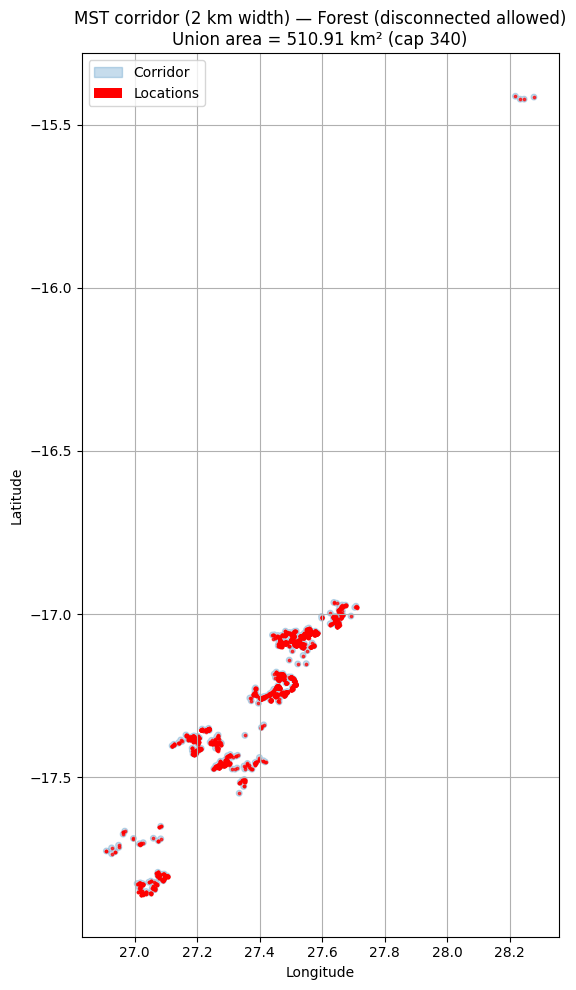

Saved corridor polygon to mst_corridor_2km.geojson


In [65]:
# -*- coding: utf-8 -*-
"""
MST corridor solver (2 km width ribbons) with safe plotting when no edges survive.

What it does
------------
1) Loads point locations (lat/lon) from CSV.
2) Projects to an appropriate UTM (meters).
3) Dedupe/snap nearby points (SNAP_TOL_M).
4) Builds a kNN graph, then an MST (minimum total length).
5) Buffers MST edges by 1 km (2 km wide) and nodes by 1 km -> corridor polygon.
6) If REQUIRE_CONNECTED=False, drops the longest edges until union area <= AREA_CAP_KM2.
7) Plots results safely even when no edges are kept.

Requires: numpy, pandas, geopandas, shapely, networkx, scikit-learn, matplotlib
"""

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# Configuration
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"   # <- make sure the filename + extension is correct
LAT_COL = "lat"
LON_COL = "long"

BOUNDARY_PATH = None                  # e.g. "sinazongwe_region.shp" or .gpkg, else None

RIBBON_HALF_WIDTH_M = 1000            # 1 km -> total ribbon width = 2 km
NODE_BUFFER_M = 1000                  # 1 km disks around points
KNN_K = 6                             # neighbors per point for candidate graph
SNAP_TOL_M = 1000                     # dedupe/merge points within 1 km (in meters)

AREA_CAP_KM2 = 340
REQUIRE_CONNECTED = False             # if True: force a single connected corridor (may exceed cap)

SAVE_GEOJSON = "mst_corridor_2km.geojson"  # set None to skip save
FIGSIZE = (10, 10)
RANDOM_SEED = 42

# -----------------------------
# Helpers
# -----------------------------
def guess_utm_epsg(lon, lat):
    """Pick a UTM EPSG based on dataset centroid."""
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def dedupe_by_snap(points_xy, tol_m):
    """Grid-snap deduplication: picks one representative per tol_m cell; returns reduced points + map."""
    if tol_m <= 0:
        idx_map = np.arange(points_xy.shape[0])
        return points_xy, idx_map
    gx = np.floor(points_xy[:, 0] / tol_m).astype(np.int64)
    gy = np.floor(points_xy[:, 1] / tol_m).astype(np.int64)
    keys = pd.Series(list(zip(gx, gy)))
    reps = []
    idx_map = np.empty(points_xy.shape[0], dtype=np.int64)
    for _, idxs in keys.groupby(keys).groups.items():
        idxs = np.array(list(idxs))
        rep = idxs[0]
        reps.append(rep)
        idx_map[idxs] = len(reps) - 1
    reduced = points_xy[np.array(reps)]
    return reduced, idx_map

def knn_edges(points_xy, k):
    """Undirected kNN edges with Euclidean weights (in meters)."""
    if len(points_xy) == 0:
        return []
    nn = NearestNeighbors(n_neighbors=min(k+1, len(points_xy)), algorithm='kd_tree')
    nn.fit(points_xy)
    dists, inds = nn.kneighbors(points_xy)
    edges = set()
    for i in range(len(points_xy)):
        for j_idx, d in zip(inds[i, 1:], dists[i, 1:]):  # skip self
            a, b = (i, int(j_idx)) if i < j_idx else (int(j_idx), i)
            edges.add((a, b, float(d)))
    return list(edges)

def mst_edges(points_xy, edges):
    """Minimum spanning tree from candidate edges."""
    G = nx.Graph()
    G.add_nodes_from(range(len(points_xy)))
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)
    T = nx.minimum_spanning_tree(G, weight='weight', algorithm='kruskal')
    return [(u, v, d['weight']) for u, v, d in T.edges(data=True)]

def build_ribbons(points_xy, edge_list, half_w, node_buf):
    """Buffers edges by half_w and nodes by node_buf; returns (edge_buffers, node_buffers, union_polygon)."""
    edge_lines = [LineString([points_xy[i], points_xy[j]]) for i, j, _ in edge_list]
    edge_gs = gpd.GeoSeries(edge_lines, crs=None) if edge_lines else gpd.GeoSeries([], crs=None)
    edge_bufs = edge_gs.buffer(half_w, cap_style=1, join_style=1) if len(edge_gs) else gpd.GeoSeries([], crs=None)
    node_pts = gpd.GeoSeries([Point(xy) for xy in points_xy], crs=None)
    node_bufs = node_pts.buffer(node_buf, cap_style=1)
    union_poly = gpd.GeoSeries(pd.concat([edge_bufs, node_bufs], ignore_index=True)).union_all()
    return edge_bufs, node_bufs, union_poly

def corridor_area_km2(union_poly):
    return float(union_poly.area) / 1_000_000.0

def drop_longest_edges_until_cap(points_xy, mst_edge_list, half_w, node_buf, area_cap_km2):
    """
    Iteratively drop the longest remaining edge; return the first set with union area <= cap,
    or the best (smallest-area) encountered configuration if none meet the cap.
    """
    edges_sorted = sorted(mst_edge_list, key=lambda e: e[2], reverse=True)
    kept = edges_sorted[:]
    best = None
    for _ in range(len(edges_sorted) + 1):
        edge_bufs, node_bufs, union_poly = build_ribbons(points_xy, kept, half_w, node_buf)
        area = corridor_area_km2(union_poly)
        if best is None or area < best[2]:
            best = (kept[:], union_poly, area)
        if area <= area_cap_km2:
            return kept, union_poly, area
        if kept:
            kept.pop(0)
        else:
            break
    return best  # (kept_edges, union_poly, area)

def is_plottable(gdf):
    """Return True iff gdf has at least one non-empty geometry and finite, valid bounds."""
    if gdf is None:
        return False
    if len(gdf) == 0:
        return False
    if "geometry" not in gdf.columns:
        return False
    if gdf.geometry.is_empty.all():
        return False
    try:
        xmin, ymin, xmax, ymax = gdf.total_bounds
    except Exception:
        return False
    if not np.isfinite([xmin, ymin, xmax, ymax]).all():
        return False
    if xmax <= xmin or ymax <= ymin:
        return False
    return True

# -----------------------------
# Load CSV + project to meters
# -----------------------------
np.random.seed(RANDOM_SEED)

df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must contain columns '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326",
)

boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)

gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)
coords_m_all = np.vstack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values]).T

coords_m, idx_map = dedupe_by_snap(coords_m_all, SNAP_TOL_M)
print(f"Points: {len(coords_m_all)} → {len(coords_m)} after {SNAP_TOL_M} m snap")

# -----------------------------
# Build kNN graph + MST
# -----------------------------
edges = knn_edges(coords_m, KNN_K)
mst = mst_edges(coords_m, edges)
total_mst_km = sum(w for _, _, w in mst) / 1000.0
print(f"MST edges: {len(mst)} | total length ≈ {total_mst_km:.1f} km")

# -----------------------------
# Corridor construction
# -----------------------------
edge_bufs, node_bufs, union_poly = build_ribbons(coords_m, mst, RIBBON_HALF_WIDTH_M, NODE_BUFFER_M)
area_km2 = corridor_area_km2(union_poly)
print(f"Connected MST corridor union area = {area_km2:.2f} km² (cap {AREA_CAP_KM2} km²)")

if REQUIRE_CONNECTED:
    if area_km2 > AREA_CAP_KM2:
        raise RuntimeError(
            "Connected MST corridor exceeds cap. MST has minimum possible total length to connect all points, "
            "so no other connected 2 km-wide corridor will fit under the 340 km² cap. "
            "Use REQUIRE_CONNECTED=False, increase SNAP_TOL_M, reduce width, or raise the cap."
        )
    kept_edges = mst
    final_union = union_poly
    final_area_km2 = area_km2
else:
    kept_edges, final_union, final_area_km2 = drop_longest_edges_until_cap(
        coords_m, mst, RIBBON_HALF_WIDTH_M, NODE_BUFFER_M, AREA_CAP_KM2
    )
    print(f"Forest corridor union area = {final_area_km2:.2f} km² (cap {AREA_CAP_KM2})")
    print(f"Edges kept: {len(kept_edges)} (dropped {len(mst) - len(kept_edges)})")

# -----------------------------
# Build GeoDataFrames (WGS84)
# -----------------------------
# Edges: convert only if there are any
if len(kept_edges) > 0:
    kept_lines = [LineString([coords_m[i], coords_m[j]]) for i, j, _ in kept_edges]
    edge_gdf_m = gpd.GeoDataFrame({"edge": range(len(kept_lines))}, geometry=kept_lines, crs=gdf_pts_m.crs)
    edge_gdf = edge_gdf_m.to_crs(epsg=4326)
else:
    edge_gdf = None
    print("No corridor edges kept (only node disks contribute to the union).")

final_union_gdf = gpd.GeoDataFrame(geometry=[final_union], crs=gdf_pts_m.crs).to_crs(epsg=4326)

# -----------------------------
# Plot (SAFE)
# -----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect("equal", adjustable="box")  # keep map sane even if a layer is empty

# Boundary (optional)
if boundary is not None and is_plottable(boundary):
    boundary.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)

# Union polygon (always exists here)
if is_plottable(final_union_gdf):
    final_union_gdf.plot(ax=ax, color="tab:blue", alpha=0.25, edgecolor="tab:blue", linewidth=0.8)
else:
    print("Warning: final_union_gdf not plottable (unexpected).")

# MST/forest edges (only if actually plottable)
if edge_gdf is not None and is_plottable(edge_gdf):
    edge_gdf.plot(ax=ax, color="tab:blue", linewidth=1.0)
else:
    print("Skipping edge overlay: no valid edge geometries to plot.")

# Original points
if is_plottable(gdf_pts):
    gdf_pts.plot(ax=ax, color="red", markersize=3, alpha=0.7)

title_conn = "Connected" if REQUIRE_CONNECTED else "Forest (disconnected allowed)"
plt.title(f"MST corridor (2 km width) — {title_conn}\nUnion area = {final_area_km2:.2f} km² (cap {AREA_CAP_KM2})")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None and is_plottable(boundary):
    handles.append(mpatches.Patch(facecolor="white", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.25, label="Corridor"))
handles.append(mpatches.Patch(facecolor="red", label="Locations"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

# -----------------------------
# Save GeoJSON (union polygon)
# -----------------------------
if SAVE_GEOJSON:
    final_union_gdf.to_file(SAVE_GEOJSON, driver="GeoJSON")
    print(f"Saved corridor polygon to {SAVE_GEOJSON}")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 5.0 MB/s eta 0:00:0000:0100:01



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Points: 3825 → 996 after 250 m snap
Using EPSG:32735 (UTM)
Solver status: Optimal
Selected cells: 0 (budget 13)
Covered points: 0 | Covered weight: 0.0


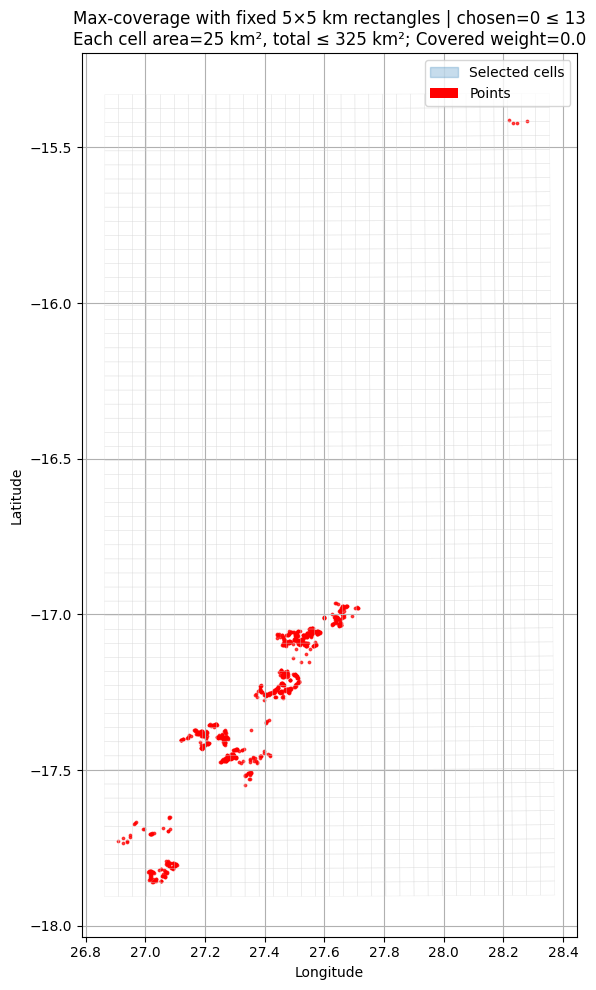

Saved selected rectangles to selected_rectangles_5km.geojson


In [66]:
# -*- coding: utf-8 -*-
"""
Max-coverage fixed rectangles:
- grid cells are 5 km x 5 km (area = 25 km², each side >= 2 km)
- choose at most 13 cells (total area = 325 km² <= 340 cap)
- maximize covered 'weight' (default = 1 per point, or use 'total_children' if present)

Requires: numpy, pandas, geopandas, shapely, matplotlib, pulp
"""

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Optional: install pulp if missing ----
try:
    import pulp
except ImportError:  # pragma: no cover
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])
    import pulp

# -----------------------------
# Config
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"  # ensure .csv
LAT_COL = "lat"
LON_COL = "long"
WEIGHT_COL = "total_children"        # set to None to count points equally

BOUNDARY_PATH = None                 # e.g., "sinazongwe_region.shp", else None

CELL_SIZE_M = 5000                   # 5 km side -> 25 km² area
MAX_CELLS = 13                       # 13 * 25 = 325 km² <= 340 cap
SNAP_TOL_M = 250                     # optional: dedupe very close points

SAVE_GEOJSON = "selected_rectangles_5km.geojson"  # set None to skip

FIGSIZE = (10, 10)
RANDOM_SEED = 42

# -----------------------------
# Helper functions
# -----------------------------
def guess_utm_epsg(lon, lat):
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def is_plottable(gdf):
    if gdf is None or len(gdf) == 0 or "geometry" not in gdf.columns:
        return False
    if gdf.geometry.is_empty.all():
        return False
    try:
        xmin, ymin, xmax, ymax = gdf.total_bounds
    except Exception:
        return False
    ar = np.array([xmin, ymin, xmax, ymax], dtype=float)
    if not np.isfinite(ar).all():
        return False
    return xmax > xmin and ymax > ymin

def dedupe_by_snap(points_xy, tol_m):
    if tol_m <= 0:
        return points_xy, np.arange(points_xy.shape[0])
    gx = np.floor(points_xy[:, 0] / tol_m).astype(np.int64)
    gy = np.floor(points_xy[:, 1] / tol_m).astype(np.int64)
    keys = pd.Series(list(zip(gx, gy)))
    reps = []
    idx_map = np.empty(points_xy.shape[0], dtype=np.int64)
    for _, idxs in keys.groupby(keys).groups.items():
        idxs = np.array(list(idxs))
        rep = idxs[0]
        reps.append(rep)
        idx_map[idxs] = len(reps) - 1
    reduced = points_xy[np.array(reps)]
    return reduced, idx_map

# -----------------------------
# Load points
# -----------------------------
df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must include '{LAT_COL}' and '{LON_COL}'.")

# weights
if WEIGHT_COL is not None and WEIGHT_COL in df.columns:
    w = df[WEIGHT_COL].fillna(0).astype(float).values
else:
    w = np.ones(len(df), dtype=float)

gdf_pts = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326"
)

# optional boundary
boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

# project to UTM meters
centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)
gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)

# dedupe near-duplicates (optional)
coords_all = np.column_stack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values])
coords, idx_map = dedupe_by_snap(coords_all, SNAP_TOL_M)
weights = []
for k in range(idx_map.max()+1):
    weights.append(w[idx_map == k].sum())
weights = np.array(weights, dtype=float)

print(f"Points: {len(coords_all)} → {len(coords)} after {SNAP_TOL_M} m snap")
print(f"Using EPSG:{epsg_utm} (UTM)")

# -----------------------------
# Build 5km x 5km grid
# -----------------------------
minx, miny = coords.min(axis=0) - CELL_SIZE_M
maxx, maxy = coords.max(axis=0) + CELL_SIZE_M

xs = np.arange(minx, maxx + CELL_SIZE_M, CELL_SIZE_M)
ys = np.arange(miny, maxy + CELL_SIZE_M, CELL_SIZE_M)

cells = []
cell_ids = []
for i in range(len(xs)-1):
    for j in range(len(ys)-1):
        poly = box(xs[i], ys[j], xs[i+1], ys[j+1])
        cells.append(poly)
        cell_ids.append((i, j))

cells_gdf_m = gpd.GeoDataFrame({"cell_id": list(range(len(cells)))}, geometry=cells, crs=f"EPSG:{epsg_utm}")

# -----------------------------
# Incidence: which point is in which cell?
# -----------------------------
pts_gs = gpd.GeoSeries([Point(xy) for xy in coords], crs=f"EPSG:{epsg_utm}")
# spatial index speedup
sindex = cells_gdf_m.sindex
covers = [[] for _ in range(len(pts_gs))]
for p_idx, p in enumerate(pts_gs):
    cand = list(sindex.query(p, predicate="contains"))
    for c in cand:
        if cells[c].contains(p):
            covers[p_idx].append(c)

# Remove points that fall in no cell (shouldn’t happen, but guard)
valid_points = [i for i in range(len(pts_gs)) if len(covers[i]) > 0]
if len(valid_points) < len(pts_gs):
    print(f"Warning: {len(pts_gs) - len(valid_points)} points outside grid padding — expanding grid recommended.")

# -----------------------------
# MIP: Max coverage with budget MAX_CELLS
# -----------------------------
prob = pulp.LpProblem("max_coverage_5km_cells", pulp.LpMaximize)

# decision vars
x = pulp.LpVariable.dicts("x_cell", range(len(cells)), 0, 1, cat=pulp.LpBinary)
y = pulp.LpVariable.dicts("y_pt", valid_points, 0, 1, cat=pulp.LpBinary)

# budget
prob += pulp.lpSum([x[c] for c in range(len(cells))]) <= MAX_CELLS

# linking: a point is covered only if at least one covering cell is chosen
for i in valid_points:
    if len(covers[i]) == 1:
        prob += y[i] <= x[covers[i][0]]
    else:
        prob += y[i] <= pulp.lpSum([x[c] for c in covers[i]])

# objective: maximize total weight of covered points
prob += pulp.lpSum([weights[i] * y[i] for i in valid_points])

# solve
solver = pulp.PULP_CBC_CMD(msg=False)
res_status = prob.solve(solver)
print("Solver status:", pulp.LpStatus[res_status])

# selected cells
chosen = [c for c in range(len(cells)) if pulp.value(x[c]) >= 0.5]
print(f"Selected cells: {len(chosen)} (budget {MAX_CELLS})")
covered_points = [i for i in valid_points if pulp.value(y[i]) >= 0.5]
total_weight = weights[covered_points].sum()
print(f"Covered points: {len(covered_points)} | Covered weight: {total_weight:.1f}")

# -----------------------------
# Build outputs in WGS84
# -----------------------------
chosen_gdf_m = cells_gdf_m.iloc[chosen].copy()
chosen_gdf = chosen_gdf_m.to_crs(epsg=4326)

pts_plot = gpd.GeoDataFrame({"w": weights}, geometry=pts_gs, crs=f"EPSG:{epsg_utm}").to_crs(epsg=4326)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect("equal", adjustable="box")

if boundary is not None and is_plottable(boundary):
    boundary.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)

# all grid (optional outline)
cells_outline = cells_gdf_m.to_crs(epsg=4326)
cells_outline.boundary.plot(ax=ax, color="lightgrey", linewidth=0.3, alpha=0.5)

# chosen cells
if is_plottable(chosen_gdf):
    chosen_gdf.plot(ax=ax, color="tab:blue", alpha=0.25, edgecolor="tab:blue", linewidth=1.0)

# points (sized by weight if available)
ms = 6 if (WEIGHT_COL is None) else None
pts_plot.plot(ax=ax, color="red", markersize=ms if ms else 3, alpha=0.7)

title = (f"Max-coverage with fixed 5×5 km rectangles | chosen={len(chosen)} ≤ {MAX_CELLS}\n"
         f"Each cell area=25 km², total ≤ {MAX_CELLS*25} km²; Covered weight={total_weight:.1f}")
plt.title(title)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None and is_plottable(boundary):
    handles.append(mpatches.Patch(facecolor="white", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.25, label="Selected cells"))
handles.append(mpatches.Patch(facecolor="red", label="Points"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

# -----------------------------
# Save
# -----------------------------
if SAVE_GEOJSON:
    chosen_gdf.to_file(SAVE_GEOJSON, driver="GeoJSON")
    print(f"Saved selected rectangles to {SAVE_GEOJSON}")


In [63]:
# -*- coding: utf-8 -*-
"""
Ellipse cover (MVEE) with robust numerics + PCA fallback + multi-start greedy merging

Per-ellipse constraints:
  - semi-axes a,b >= 1000 m  (→ diameters >= 2 km)
  - area >= 25 km²           (πab >= 25e6 m²) [expand cheaper axis only]
Objective:
  - minimize SUM of ellipse areas, with SUM ≤ 340 km²

Strategy:
  - multi-start: snap to 2 km grid with random offsets
  - MVEE per cluster (Khachiyan) with strong regularization
  - If MVEE is ill-conditioned/degenerate: PCA-based ellipse fallback
  - greedy merges by least area increase, stop once ≤ 13 ellipses
"""

import os
import random
import heapq
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Configuration
# -----------------------------
CSV_PATH = "orphanhood_prev_hh"   # << ensure the actual filename (with .csv)
LAT_COL = "lat"
LON_COL = "long"

BOUNDARY_PATH = None                  # e.g., "sinazongwe_region.shp" or .gpkg, else None

# Constraints
MIN_SEMI_AXIS_M = 1000                # semi-axes >= 1 km
MIN_AREA_M2 = 25_000_000              # 25 km²
AREA_CAP_KM2 = 340
MAX_ELLIPSES = int(AREA_CAP_KM2 // 25)  # <= 13 by area lower bound

# Multi-start + snapping
SNAP_GRID_M = 2000
RANDOM_RESTARTS = 60
RANDOM_SEED = 42
VERBOSE = True

# Rendering / output
ELLIPSE_NPTS = 256
SAVE_GEOJSON_BEST = "ellipses_mvee_multistart.geojson"  # set None to skip saving


# -----------------------------
# CRS + Snapping helpers
# -----------------------------
def guess_utm_epsg(lon, lat):
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def snap_with_offset(coords_m, offset_x, offset_y, snap=SNAP_GRID_M):
    ix = ((coords_m[:, 0] - offset_x) // snap).astype(np.int64)
    iy = ((coords_m[:, 1] - offset_y) // snap).astype(np.int64)
    keys = pd.Series(list(zip(ix, iy)))
    clusters = {}
    for _, idxs in keys.groupby(keys).groups.items():
        cid = len(clusters)
        clusters[cid] = coords_m[np.array(list(idxs))]
    return clusters


# -----------------------------
# MVEE + PCA fallback builders
# -----------------------------
def mvee(points, tol=1e-7, max_iter=2000, reg=1e-9):
    """Robust Khachiyan MVEE with Tikhonov regularization."""
    P = np.asarray(points, dtype=float)  # (n,2)
    n, d = P.shape
    if n == 1:
        c = P[0]
        A = np.eye(d)
        return c, A

    PT = P.T
    u = np.ones(n) / n

    for _ in range(max_iter):
        X = PT @ (u[:, None] * P)  # d x d
        try:
            X_inv = np.linalg.inv(X + reg * np.eye(d))
        except np.linalg.LinAlgError:
            X_inv = np.linalg.inv(X + 1e-6 * np.eye(d))
        M = np.einsum('ni,ij,nj->n', P, X_inv, P)
        j = int(np.argmax(M)); MJ = M[j]
        step = (MJ - d - 1.0) / ((d + 1.0) * (MJ - 1.0))
        new_u = (1.0 - step) * u
        new_u[j] += step
        if np.linalg.norm(new_u - u) < tol:
            u = new_u; break
        u = new_u

    c = (u @ P).astype(float)
    S = P - c
    SuS = (S.T * u) @ S
    try:
        A = (1.0 / d) * np.linalg.inv(SuS + reg * np.eye(d))
    except np.linalg.LinAlgError:
        A = (1.0 / d) * np.linalg.inv(SuS + 1e-6 * np.eye(d))
    return c, A

def ellipse_axes_from_A(A):
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, 1e-18, None)
    axes = 1.0 / np.sqrt(vals)
    order = np.argsort(axes)[::-1]
    a, b = float(axes[order[0]]), float(axes[order[1]])
    U = vecs[:, order]
    return a, b, U

def ellipse_polygon(center, U, a, b, npts=ELLIPSE_NPTS):
    t = np.linspace(0, 2*np.pi, npts, endpoint=False)
    local = np.stack([a*np.cos(t), b*np.sin(t)], axis=0)
    world = (U @ local).T + center
    return Polygon(world)

def enforce_axis_area_constraints(a, b, min_semi=MIN_SEMI_AXIS_M, min_area=MIN_AREA_M2):
    if b > a: a, b = b, a
    a_eff = max(a, min_semi)
    b_eff = max(b, min_semi)
    area = np.pi * a_eff * b_eff
    if area < min_area:
        a_needed = max(a_eff, min_area / (np.pi * b_eff))
        b_needed = max(b_eff, min_area / (np.pi * a_eff))
        if (a_needed - a_eff) <= (b_needed - b_eff):
            a_eff = a_needed
        else:
            b_eff = b_needed
    return float(a_eff), float(b_eff)

def pca_envelope_ellipse(points):
    """
    PCA fallback ellipse:
      - center = mean
      - axes = half-range along PC directions (+ small pad)
    """
    P = np.asarray(points, float)
    c = P.mean(axis=0)
    X = P - c
    # handle n=1 or all identical
    if np.allclose(X, 0):
        U = np.eye(2)
        a0 = b0 = 1e-6
        return c, U, a0, b0
    C = (X.T @ X) / max(len(P)-1, 1)
    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    U = vecs[:, order]           # columns: major, minor
    Y = X @ U                    # coords in PC frame
    y_max = np.max(Y, axis=0); y_min = np.min(Y, axis=0)
    half_ranges = 0.5 * (y_max - y_min)
    # pad a bit in case of zero range
    half_ranges = np.maximum(half_ranges, np.array([1e-6, 1e-6]))
    a0, b0 = float(half_ranges[0]), float(half_ranges[1])
    # if ranges are extremely tiny (almost a point), set tiny defaults
    if a0 < 1e-6 and b0 < 1e-6:
        a0 = b0 = 1e-6
    return c, U, a0, b0

def ellipse_from_points(points):
    """
    MVEE -> (a,b,U) with PCA fallback when MVEE is ill-conditioned/degenerate.
    """
    P = np.asarray(points, float)
    n = len(P)

    if n == 0:
        raise ValueError("Empty cluster encountered.")
    if n == 1:
        c = P[0]; U = np.eye(2); a0 = b0 = MIN_SEMI_AXIS_M
        a_eff, b_eff = enforce_axis_area_constraints(a0, b0)
        return ellipse_polygon(c, U, a_eff, b_eff), float(np.pi*a_eff*b_eff)

    # Try MVEE first
    try:
        c, A = mvee(P)
        a0, b0, U = ellipse_axes_from_A(A)
        # If MVEE axes look degenerate (too small or huge condition), use PCA fallback
        cond = np.linalg.cond(A)
        if not np.isfinite(cond) or cond > 1e15 or (a0 < 1e-6 and b0 < 1e-6):
            raise np.linalg.LinAlgError("MVEE ill-conditioned; switching to PCA fallback.")
    except np.linalg.LinAlgError:
        c, U, a0, b0 = pca_envelope_ellipse(P)

    # Enforce constraints
    a_eff, b_eff = enforce_axis_area_constraints(a0, b0)
    poly = ellipse_polygon(c, U, a_eff, b_eff)
    area = float(np.pi * a_eff * b_eff)
    return poly, area


# -----------------------------
# Greedy merging (one restart)
# -----------------------------
def greedy_once_ellipses(coords_m, ox, oy, max_ellipses=MAX_ELLIPSES):
    clusters = snap_with_offset(coords_m, ox, oy, SNAP_GRID_M)
    active = set(clusters.keys())

    ell_info = {}  # cid -> (poly, area_m2)
    for cid, pts in clusters.items():
        poly, area = ellipse_from_points(pts)
        ell_info[cid] = (poly, area)

    def total_area_m2():
        return sum(a for _, a in ell_info.values())

    def merged_area(a_xy, b_xy):
        merged = np.vstack([a_xy, b_xy])
        return ellipse_from_points(merged)[1]

    def pair_delta(cid1, cid2):
        a_xy = clusters[cid1]; b_xy = clusters[cid2]
        a_area = ell_info[cid1][1]; b_area = ell_info[cid2][1]
        m_area = merged_area(a_xy, b_xy)
        return m_area - (a_area + b_area)

    ids = list(active)
    heap = []
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            d = pair_delta(ids[i], ids[j])
            heapq.heappush(heap, (d, ids[i], ids[j]))

    while len(active) > max_ellipses:
        if not heap:
            break
        d, c1, c2 = heapq.heappop(heap)
        if c1 not in active or c2 not in active:
            continue
        merged_pts = np.vstack([clusters[c1], clusters[c2]])
        clusters[c1] = merged_pts
        poly, area = ellipse_from_points(merged_pts)
        ell_info[c1] = (poly, area)
        del clusters[c2]; del ell_info[c2]
        active.remove(c2)
        for other in list(active):
            if other == c1:
                continue
            d_new = pair_delta(c1, other)
            heapq.heappush(heap, (d_new, c1, other))

    if len(active) > max_ellipses:
        return None

    total_km2 = total_area_m2() / 1_000_000.0
    ellipses = [ell_info[cid][0] for cid in active]
    return ellipses, total_km2


# -----------------------------
# Load + project to meters (UTM)
# -----------------------------
df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must contain '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326",
)

boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)
gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)
coords_m = np.vstack([gdf_pts_m.geometry.x.values, gdf_pts_m.geometry.y.values]).T

# -----------------------------
# Multi-start search
# -----------------------------
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

best = None
best_offset = None

for r in range(RANDOM_RESTARTS):
    ox = random.uniform(0, SNAP_GRID_M)
    oy = random.uniform(0, SNAP_GRID_M)
    res = greedy_once_ellipses(coords_m, ox, oy, MAX_ELLIPSES)
    if res is None:
        if VERBOSE:
            print(f"[{r+1}/{RANDOM_RESTARTS}] offset=({ox:.0f},{oy:.0f}) -> failed (too many clusters)")
        continue

    ellipses, summed_area_km2 = res
    ell_gs_m = gpd.GeoSeries(ellipses, crs=gdf_pts_m.crs)
    union_m = ell_gs_m.union_all()
    union_area_km2 = union_m.area / 1_000_000.0

    if VERBOSE:
        print(f"[{r+1}/{RANDOM_RESTARTS}] offset=({ox:.0f},{oy:.0f}) -> "
              f"ellipses={len(ellipses)}, sum={summed_area_km2:.2f} km², union={union_area_km2:.2f} km²")

    if summed_area_km2 <= AREA_CAP_KM2:
        if (best is None) or (summed_area_km2 < best['sum_km2']):
            best = {"ellipses_m": ellipses, "sum_km2": summed_area_km2, "union_km2": union_area_km2}
            best_offset = (ox, oy)

# -----------------------------
# Report / Plot / Save
# -----------------------------
if best is None:
    raise RuntimeError(
        f"No feasible set found across {RANDOM_RESTARTS} restarts with ellipses. "
        f"It may be infeasible under semi-axes≥1 km, area≥25 km², sum≤{AREA_CAP_KM2} km². "
        f"Increase RANDOM_RESTARTS, change SNAP_GRID_M, or relax constraints."
    )

print("\n=== Best feasible solution (ellipses) ===")
print(f"Total ellipses: {len(best['ellipses_m'])}")
print(f"Summed area: {best['sum_km2']:.2f} km² (cap {AREA_CAP_KM2})")
print(f"Union area:  {best['union_km2']:.2f} km²")
print(f"Best grid offset: ({best_offset[0]:.1f} m, {best_offset[1]:.1f} m)")

ellipses_m = best["ellipses_m"]
ell_gdf_m = gpd.GeoDataFrame({"id": range(len(ellipses_m))}, geometry=ellipses_m, crs=gdf_pts_m.crs)
ell_gdf = ell_gdf_m.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 10))
if boundary is not None:
    boundary.plot(ax=ax, color="lightgrey", edgecolor="black")

ell_gdf.boundary.plot(ax=ax, linewidth=1.2, color="black")
ell_gdf.plot(ax=ax, alpha=0.25, edgecolor="black")
gdf_pts.plot(ax=ax, color="red", markersize=3, alpha=0.6)

plt.title(
    f"MVEE ellipses (multi-start greedy) — semi-axes≥1 km, area≥25 km²\n"
    f"n={len(ellipses_m)} | sum={best['sum_km2']:.2f} km² (cap {AREA_CAP_KM2}); union={best['union_km2']:.2f} km²"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = []
if boundary is not None:
    handles.append(mpatches.Patch(facecolor="lightgrey", edgecolor="black", label="Boundary"))
handles.append(mpatches.Patch(facecolor="lightblue", edgecolor="black", label="Ellipses"))
handles.append(mpatches.Patch(facecolor="red", label="Locations"))
plt.legend(handles=handles, loc="best")

plt.tight_layout(); plt.show()

if SAVE_GEOJSON_BEST:
    ell_gdf.to_file(SAVE_GEOJSON_BEST, driver="GeoJSON")
    print(f"Saved ellipses to {SAVE_GEOJSON_BEST}")


[1/60] offset=(1279,50) -> ellipses=13, sum=703.69 km², union=654.75 km²
[2/60] offset=(550,446) -> ellipses=13, sum=807.53 km², union=747.80 km²
[3/60] offset=(1473,1353) -> ellipses=13, sum=1094.57 km², union=1019.54 km²
[4/60] offset=(1784,174) -> ellipses=13, sum=782.69 km², union=730.27 km²
[5/60] offset=(844,60) -> ellipses=13, sum=711.43 km², union=689.56 km²
[6/60] offset=(437,1011) -> ellipses=13, sum=783.98 km², union=724.41 km²
[7/60] offset=(53,398) -> ellipses=13, sum=704.75 km², union=662.71 km²
[8/60] offset=(1300,1090) -> ellipses=13, sum=696.64 km², union=650.00 km²
[9/60] offset=(441,1179) -> ellipses=13, sum=678.57 km², union=653.18 km²
[10/60] offset=(1619,13) -> ellipses=13, sum=588.98 km², union=567.35 km²
[11/60] offset=(1612,1396) -> ellipses=13, sum=754.21 km², union=723.84 km²
[12/60] offset=(681,311) -> ellipses=13, sum=885.93 km², union=821.71 km²
[13/60] offset=(1914,673) -> ellipses=13, sum=1168.57 km², union=1102.41 km²
[14/60] offset=(185,193) -> ellipse

RuntimeError: No feasible set found across 60 restarts with ellipses. It may be infeasible under semi-axes≥1 km, area≥25 km², sum≤340 km². Increase RANDOM_RESTARTS, change SNAP_GRID_M, or relax constraints.

In [49]:
print(best)

None


Using UTM: EPSG:32735
Surveyed points: 3825
Candidate centers: 160 (from 2 km snap)
Trimmed candidate rectangles to 8000 (MAX_RECTANGLES=8000).
Solver status: Optimal
Selected rectangles: 12
Total selected area: 340.00 km² (cap 340.0)
Covered points: 3494 / 3825 (91.3%)


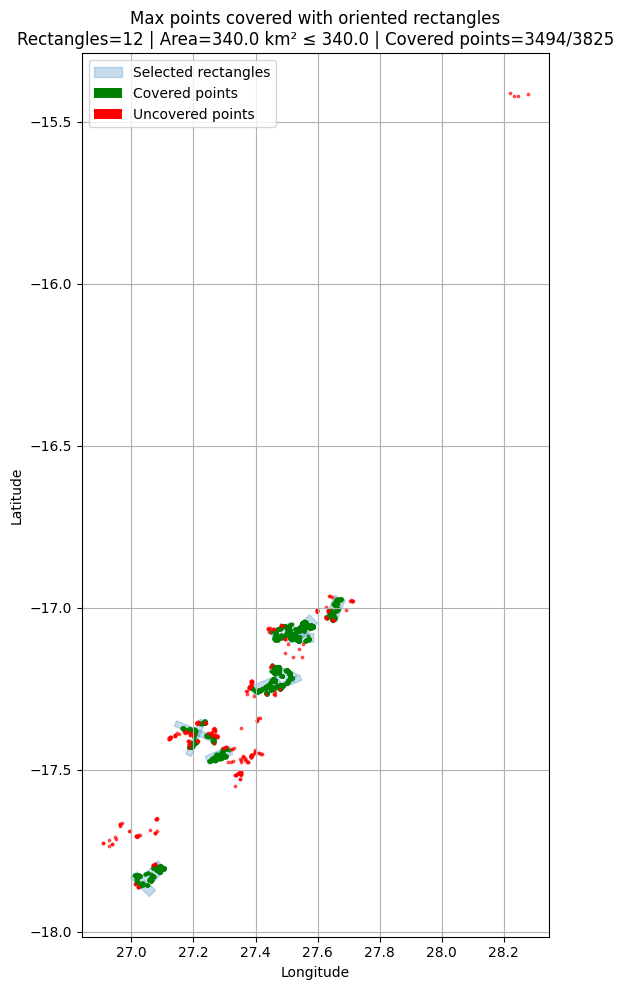

Saved selected rectangles to selected_rectangles_max_points.geojson
Saved shapefiles:
  selected_rectangles_shp/rectangles_utm.shp
  selected_rectangles_shp/rectangles_wgs84.shp
Saved union shapefiles:
  selected_rectangles_shp/rectangles_union_utm.shp
  selected_rectangles_shp/rectangles_union_wgs84.shp


/var/folders/f9/6qm__g0x43z2c3q6_6g_q9cc0000gn/T/ipykernel_74849/1866001129.py:375: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union_m = selected_gdf_m_shp.unary_union
/var/folders/f9/6qm__g0x43z2c3q6_6g_q9cc0000gn/T/ipykernel_74849/1866001129.py:382: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union_wgs = selected_gdf_wgs84_shp.unary_union


In [69]:
# -*- coding: utf-8 -*-
"""
Maximize number of surveyed points covered with rectangles under:
  - each side ≥ 2 km
  - area ≥ 25 km²
  - total selected area ≤ 340 km²

Shapes: oriented rectangles (multiple sizes & angles).
Demand units: original surveyed points (equal weight = 1 each).

Outputs:
  - Plot of selected rectangles + covered/uncovered points
  - GeoJSON of selected rectangles (WGS84)
  - Shapefiles of selected rectangles in UTM (meters) and WGS84 (lon/lat)
  - Shapefiles of the union polygon (UTM & WGS84)

Requires: numpy, pandas, geopandas, shapely, matplotlib, pulp
"""

import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely import affinity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Install PuLP if missing (CBC solver) ----
try:
    import pulp
except ImportError:  # pragma: no cover
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])
    import pulp

# =========================
# Configuration
# =========================
CSV_PATH = "orphanhood_prev_hh"     # <- ensure correct filename with extension
LAT_COL = "lat"
LON_COL = "long"

BOUNDARY_PATH = None                    # e.g., "sinazongwe_region.shp" or .gpkg, else None

# Constraints
MIN_SIDE_KM = 2.0
MIN_AREA_KM2 = 25.0
AREA_CAP_KM2 = 340.0

# Candidate rectangle sizes (width ≤ length), all must satisfy MIN_SIDE & MIN_AREA
RECT_SIZES_KM = [
    (2, 13), (2, 15),
    (3, 9),  (3, 10),
    (4, 7),  (4, 8),
    (5, 5),  (5, 6),
]

# Orientations to try (degrees)
ANGLES_DEG = [0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5]

# Where to place rectangles? Use 2 km–snapped “hotspots” from points.
SNAP_M = 2000               # 2 km snap for candidate centers
MAX_CENTER_CANDIDATES = 500 # limit how many centers we allow (keeps MILP tractable)
MAX_RECTANGLES = 8000       # safety cap on candidate rectangles

# Plot / Save
FIGSIZE = (10, 10)
SAVE_GEOJSON = "selected_rectangles_max_points.geojson"  # set None to skip

# Shapefile outputs
SHP_DIR = "selected_rectangles_shp"
SHP_UTM   = os.path.join(SHP_DIR, "rectangles_utm.shp")
SHP_WGS84 = os.path.join(SHP_DIR, "rectangles_wgs84.shp")
SHP_UNION_UTM   = os.path.join(SHP_DIR, "rectangles_union_utm.shp")
SHP_UNION_WGS84 = os.path.join(SHP_DIR, "rectangles_union_wgs84.shp")

RANDOM_SEED = 42

# =========================
# Helpers
# =========================
def guess_utm_epsg(lon, lat):
    """Pick a UTM EPSG based on dataset centroid."""
    zone = int(np.floor((lon + 180) / 6) + 1)
    return (32600 if lat >= 0 else 32700) + zone

def is_plottable(gdf):
    """Safe plotting guard."""
    if gdf is None or len(gdf) == 0 or "geometry" not in gdf.columns:
        return False
    if gdf.geometry.is_empty.all():
        return False
    try:
        xmin, ymin, xmax, ymax = gdf.total_bounds
    except Exception:
        return False
    arr = np.array([xmin, ymin, xmax, ymax], dtype=float)
    if not np.isfinite(arr).all():
        return False
    return xmax > xmin and ymax > ymin

def build_hotspots_from_points(gdf_pts_m, snap_m=SNAP_M, max_centers=MAX_CENTER_CANDIDATES):
    """Snap points to grid (snap_m), aggregate counts, and return top cells as candidate centers."""
    x = gdf_pts_m.geometry.x.values
    y = gdf_pts_m.geometry.y.values
    gx = np.round(x / snap_m).astype(int)
    gy = np.round(y / snap_m).astype(int)
    df_tmp = pd.DataFrame({"gx": gx, "gy": gy})
    agg = df_tmp.value_counts(["gx", "gy"]).reset_index(name="count")
    agg["cx"] = agg["gx"] * snap_m
    agg["cy"] = agg["gy"] * snap_m
    agg = agg.sort_values("count", ascending=False).head(max_centers).reset_index(drop=True)
    centers = gpd.GeoDataFrame(agg, geometry=gpd.points_from_xy(agg["cx"], agg["cy"]), crs=gdf_pts_m.crs)
    return centers

def rectangle_at(center_xy, width_m, length_m, angle_deg):
    """Axis-aligned rectangle centered at (cx,cy) then rotated around the center."""
    cx, cy = center_xy
    poly = box(cx - length_m/2, cy - width_m/2, cx + length_m/2, cy + width_m/2)
    if angle_deg % 180 != 0:
        poly = affinity.rotate(poly, angle_deg, origin=(cx, cy), use_radians=False)
    return poly

def prep_cols_for_shp(gdf):
    """Prepare attribute-friendly columns for Shapefile (<=10 chars)."""
    gdf = gdf.copy()
    # Keep important columns
    keep_cols = []
    for c in ["center_id", "size_id", "angle_id", "area_km2"]:
        if c in gdf.columns:
            keep_cols.append(c)
    keep_cols.append("geometry")
    gdf = gdf[keep_cols]
    # Rename to <= 10 chars
    ren = {"center_id": "center_id",
           "size_id":   "size_id",
           "angle_id":  "angle",
           "area_km2":  "area_km2"}
    gdf = gdf.rename(columns=ren)
    # Cast dtypes
    for c in ["center_id", "size_id", "angle"]:
        if c in gdf.columns:
            gdf[c] = gdf[c].astype("int64")
    if "area_km2" in gdf.columns:
        gdf["area_km2"] = gdf["area_km2"].astype(float)
    return gdf

# =========================
# Load data & project to meters
# =========================
np.random.seed(RANDOM_SEED)

df = pd.read_csv(CSV_PATH)
if LAT_COL not in df.columns or LON_COL not in df.columns:
    raise ValueError(f"CSV must include '{LAT_COL}' and '{LON_COL}'.")

gdf_pts = gpd.GeoDataFrame(
    df[[LAT_COL, LON_COL]].copy(),
    geometry=gpd.points_from_xy(df[LON_COL], df[LAT_COL]),
    crs="EPSG:4326"
)

boundary = None
if BOUNDARY_PATH is not None and os.path.exists(BOUNDARY_PATH):
    boundary = gpd.read_file(BOUNDARY_PATH)
    if boundary.crs is None or boundary.crs.to_string() != "EPSG:4326":
        boundary = boundary.to_crs(epsg=4326)

# Choose UTM for accurate meters
centroid = gdf_pts.geometry.union_all().centroid
epsg_utm = guess_utm_epsg(centroid.x, centroid.y)
gdf_pts_m = gdf_pts.to_crs(epsg=epsg_utm)
print(f"Using UTM: EPSG:{epsg_utm}")

# Demand points are the original surveyed points (weight 1 each)
points_m = gdf_pts_m.geometry.values
N = len(points_m)
print(f"Surveyed points: {N}")

# =========================
# Candidate rectangle centers (hotspots)
# =========================
centers = build_hotspots_from_points(gdf_pts_m, SNAP_M, MAX_CENTER_CANDIDATES)
print(f"Candidate centers: {len(centers)} (from 2 km snap)")

# =========================
# Candidate rectangles (sizes & angles), filtered by constraints
# =========================
sizes_ok = []
for (w_km, l_km) in RECT_SIZES_KM:
    if w_km < MIN_SIDE_KM or l_km < MIN_SIDE_KM:
        continue
    area_km2 = w_km * l_km
    if area_km2 < MIN_AREA_KM2:
        continue
    sizes_ok.append((w_km * 1000.0, l_km * 1000.0, area_km2))  # (width_m, length_m, area_km2)

if not sizes_ok:
    raise RuntimeError("No rectangle sizes satisfy the min-side and min-area constraints.")

rect_polys = []
rect_area_km2 = []
rect_center_id = []
rect_size_id = []
rect_angle_id = []

for ci, row in centers.iterrows():
    cx, cy = float(row["cx"]), float(row["cy"])
    for si, (w_m, l_m, area_km2) in enumerate(sizes_ok):
        for ai, ang in enumerate(ANGLES_DEG):
            poly = rectangle_at((cx, cy), w_m, l_m, ang)
            rect_polys.append(poly)
            rect_area_km2.append(area_km2)
            rect_center_id.append(ci)
            rect_size_id.append(si)
            rect_angle_id.append(ai)

rects_gdf_m = gpd.GeoDataFrame(
    {
        "center_id": rect_center_id,
        "size_id": rect_size_id,
        "angle_id": rect_angle_id,
        "area_km2": rect_area_km2
    },
    geometry=rect_polys,
    crs=gdf_pts_m.crs
)

if len(rects_gdf_m) > MAX_RECTANGLES:
    rects_gdf_m = rects_gdf_m.iloc[:MAX_RECTANGLES].copy()
    print(f"Trimmed candidate rectangles to {len(rects_gdf_m)} (MAX_RECTANGLES={MAX_RECTANGLES}).")
else:
    print(f"Candidate rectangles: {len(rects_gdf_m)}")

# Optional: clip to boundary to avoid rectangles far outside (keeps area accounting the same)
if boundary is not None and len(boundary) > 0:
    boundary_m = boundary.to_crs(epsg=epsg_utm)
    # keep rectangles whose centroid lies in boundary (cheap)
    keep_mask = rects_gdf_m.centroid.within(boundary_m.unary_union)
    before = len(rects_gdf_m)
    rects_gdf_m = rects_gdf_m[keep_mask].reset_index(drop=True)
    print(f"Clipped candidates to boundary: {before} -> {len(rects_gdf_m)}")

# =========================
# Incidence: which rectangles cover which points?
# (Use point spatial index for speed: query by rect bounds, then precise contains)
# =========================
pts_gdf_m = gpd.GeoDataFrame({"id": range(N)}, geometry=gpd.GeoSeries(points_m, crs=gdf_pts_m.crs))
pts_sindex = pts_gdf_m.sindex

covered_by_rect = [[] for _ in range(len(rects_gdf_m))]

for r, poly in enumerate(rects_gdf_m.geometry.values):
    # quick bbox query
    cand = list(pts_sindex.query(poly, predicate="intersects"))
    if not cand:
        continue
    # precise test
    inside = [i for i in cand if poly.contains(points_m[i])]
    covered_by_rect[r] = inside

# =========================
# MILP: Budgeted Max Coverage (maximize #points covered)
# Variables:
#   x_r ∈ {0,1} select rectangle r
#   y_i ∈ {0,1} point i is covered
# Constraints:
#   sum(area_r * x_r) ≤ AREA_CAP_KM2
#   ∀i: y_i ≤ sum_{r covering i} x_r
# Objective: maximize sum(y_i)
# =========================
prob = pulp.LpProblem("max_points_coverage_rectangles", pulp.LpMaximize)

R = len(rects_gdf_m)
x = pulp.LpVariable.dicts("x", range(R), lowBound=0, upBound=1, cat=pulp.LpBinary)
y = pulp.LpVariable.dicts("y", range(N), lowBound=0, upBound=1, cat=pulp.LpBinary)

# Area budget
prob += pulp.lpSum(rects_gdf_m["area_km2"].iloc[r] * x[r] for r in range(R)) <= AREA_CAP_KM2

# Linking: a point can be covered only if at least one covering rectangle is chosen
for i in range(N):
    rects_covering_i = [r for r in range(R) if i in covered_by_rect[r]]
    if rects_covering_i:
        prob += y[i] <= pulp.lpSum(x[r] for r in rects_covering_i)
    else:
        prob += y[i] == 0

# Objective: maximize # of covered points
prob += pulp.lpSum(y[i] for i in range(N))

# Solve
solver = pulp.PULP_CBC_CMD(msg=False)
status = prob.solve(solver)
print("Solver status:", pulp.LpStatus[status])

selected_idx = [r for r in range(R) if pulp.value(x[r]) >= 0.5]
covered_idx  = [i for i in range(N) if pulp.value(y[i]) >= 0.5]
total_area   = float(sum(rects_gdf_m["area_km2"].iloc[r] for r in selected_idx))

print(f"Selected rectangles: {len(selected_idx)}")
print(f"Total selected area: {total_area:.2f} km² (cap {AREA_CAP_KM2})")
print(f"Covered points: {len(covered_idx)} / {N} ({100.0*len(covered_idx)/max(1,N):.1f}%)")

# =========================
# Outputs & Plot
# =========================
selected_gdf_m = rects_gdf_m.iloc[selected_idx].copy()
selected_gdf   = selected_gdf_m.to_crs(epsg=4326)
pts_plot       = gdf_pts_m.to_crs(epsg=4326)

# covered / uncovered markers
covered_mask = np.zeros(N, dtype=bool)
covered_mask[covered_idx] = True
pts_plot["covered"] = covered_mask

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_aspect("equal", adjustable="box")

# Boundary (optional)
if boundary is not None and is_plottable(boundary):
    boundary.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)

# Selected rectangles
if is_plottable(selected_gdf):
    selected_gdf.plot(ax=ax, color="tab:blue", alpha=0.25, edgecolor="tab:blue", linewidth=1.0)

# Points: covered vs uncovered
if is_plottable(pts_plot):
    pts_plot[pts_plot["covered"]].plot(ax=ax, color="green", markersize=4, alpha=0.8, label="Covered")
    pts_plot[~pts_plot["covered"]].plot(ax=ax, color="red", markersize=3, alpha=0.6, label="Uncovered")

plt.title(
    f"Max points covered with oriented rectangles\n"
    f"Rectangles={len(selected_idx)} | Area={total_area:.1f} km² ≤ {AREA_CAP_KM2} | "
    f"Covered points={len(covered_idx)}/{N}"
)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

handles = [
    mpatches.Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.25, label="Selected rectangles"),
    mpatches.Patch(facecolor="green", label="Covered points"),
    mpatches.Patch(facecolor="red",   label="Uncovered points"),
]
plt.legend(handles=handles, loc="best")
plt.tight_layout(); plt.show()

# =========================
# Save GeoJSON of selected rectangles (WGS84)
# =========================
if SAVE_GEOJSON:
    selected_gdf.to_file(SAVE_GEOJSON, driver="GeoJSON")
    print(f"Saved selected rectangles to {SAVE_GEOJSON}")

# =========================
# Save ESRI Shapefiles (selected rectangles + union)
# =========================
os.makedirs(SHP_DIR, exist_ok=True)

if len(selected_idx) == 0:
    print("No rectangles selected — skipping Shapefile export.")
else:
    # Prepare attribute-friendly copies
    selected_gdf_m_shp     = prep_cols_for_shp(selected_gdf_m)
    selected_gdf_wgs84_shp = prep_cols_for_shp(selected_gdf)

    # Individual rectangles
    selected_gdf_m_shp.to_file(SHP_UTM,   driver="ESRI Shapefile", encoding="utf-8")
    selected_gdf_wgs84_shp.to_file(SHP_WGS84, driver="ESRI Shapefile", encoding="utf-8")
    print(f"Saved shapefiles:\n  {SHP_UTM}\n  {SHP_WGS84}")

    # UNION polygons
    union_m = selected_gdf_m_shp.unary_union
    union_m_gdf = gpd.GeoDataFrame(
        {"id":[1], "area_km2":[float(selected_gdf_m_shp["area_km2"].sum())]},
        geometry=[union_m], crs=selected_gdf_m_shp.crs
    )
    union_m_gdf.to_file(SHP_UNION_UTM, driver="ESRI Shapefile", encoding="utf-8")

    union_wgs = selected_gdf_wgs84_shp.unary_union
    union_wgs_gdf = gpd.GeoDataFrame(
        {"id":[1], "area_km2":[float(selected_gdf_wgs84_shp["area_km2"].sum())]},
        geometry=[union_wgs], crs=selected_gdf_wgs84_shp.crs
    )
    union_wgs_gdf.to_file(SHP_UNION_WGS84, driver="ESRI Shapefile", encoding="utf-8")

    print(f"Saved union shapefiles:\n  {SHP_UNION_UTM}\n  {SHP_UNION_WGS84}")


Loaded rects_wgs84: 12 features | CRS=EPSG:4326
Loaded union_wgs84: 1 features | CRS=EPSG:4326
Loaded rects_utm: 12 features | CRS=EPSG:32735
Loaded union_utm: 1 features | CRS=EPSG:32735


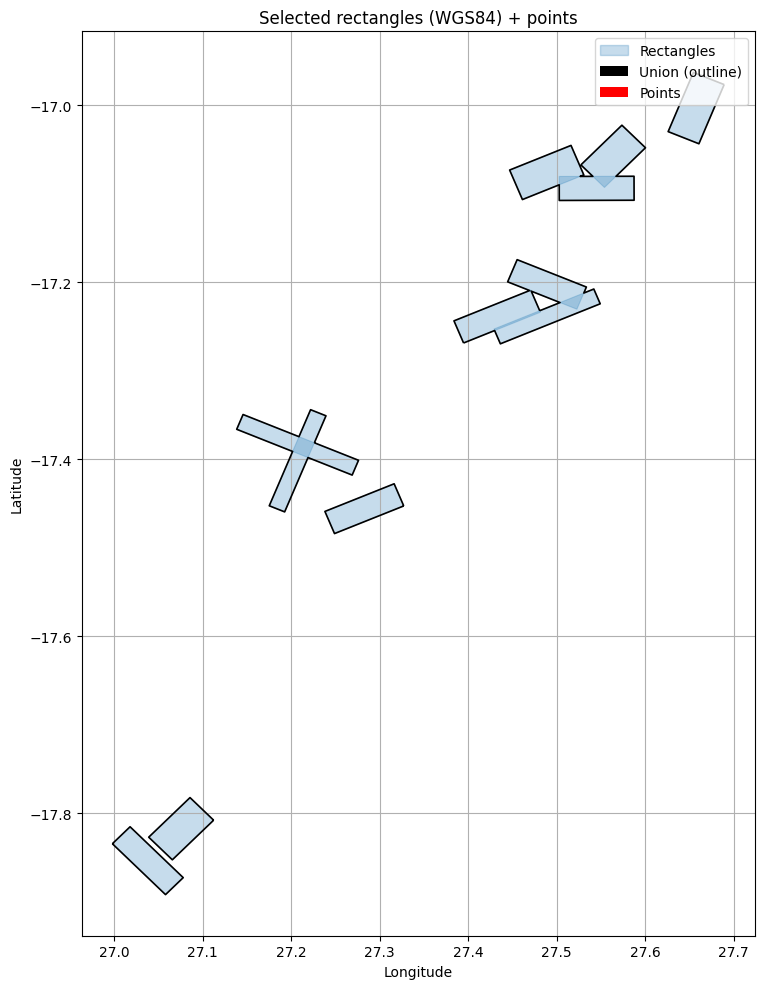

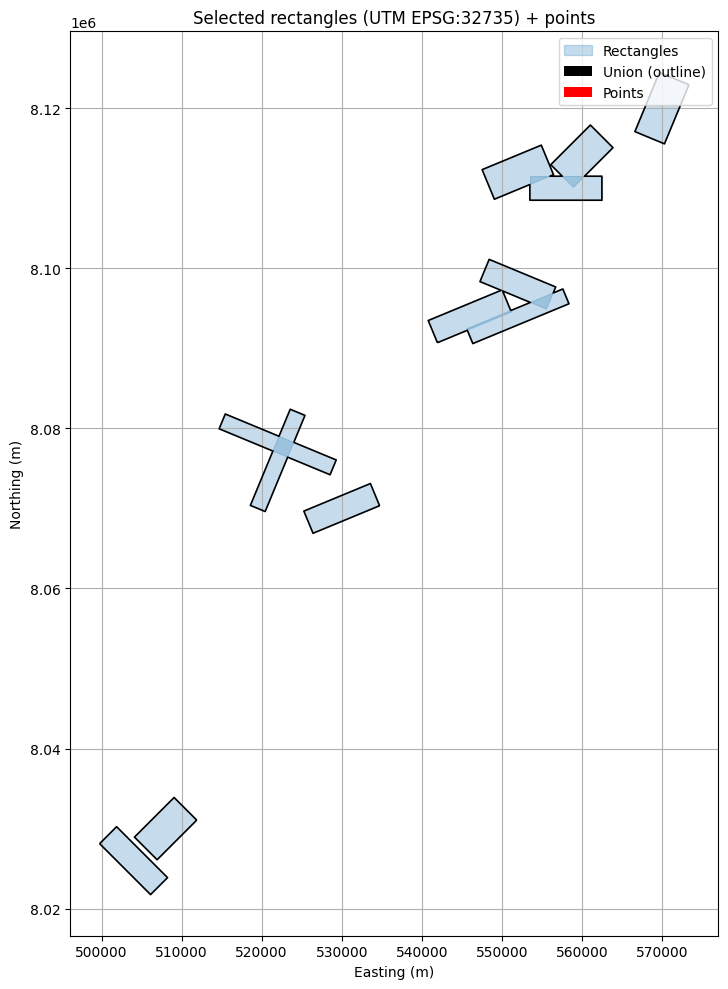

In [72]:
# --- Verify & plot the exported shapefiles ---

import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# If you used different names/dirs above, update these:
SHP_DIR = "selected_rectangles_shp"
SHP_UTM   = os.path.join(SHP_DIR, "rectangles_utm.shp")
SHP_WGS84 = os.path.join(SHP_DIR, "rectangles_wgs84.shp")
SHP_UNION_UTM   = os.path.join(SHP_DIR, "rectangles_union_utm.shp")
SHP_UNION_WGS84 = os.path.join(SHP_DIR, "rectangles_union_wgs84.shp")

CSV_PATH = "orphanhood_prev_hh.csv"  # same CSV as before
LAT_COL, LON_COL = "lat", "long"

def is_plottable(gdf):
    if gdf is None or len(gdf) == 0 or "geometry" not in gdf.columns:
        return False
    if gdf.geometry.is_empty.all():
        return False
    try:
        xmin, ymin, xmax, ymax = gdf.total_bounds
        arr = np.array([xmin, ymin, xmax, ymax], dtype=float)
    except Exception:
        return False
    if not np.isfinite(arr).all():
        return False
    return xmax > xmin and ymax > ymin

def safe_equal_aspect(ax, gdf):
    # Use equal aspect only if bounds are sane
    if is_plottable(gdf):
        ax.set_aspect("equal", adjustable="box")

# -------------------
# Load layers
# -------------------
layers = {}
for name, path in [
    ("rects_wgs84", SHP_WGS84),
    ("union_wgs84", SHP_UNION_WGS84),
    ("rects_utm",   SHP_UTM),
    ("union_utm",   SHP_UNION_UTM),
]:
    if os.path.exists(path):
        layers[name] = gpd.read_file(path)
        print(f"Loaded {name}: {len(layers[name])} features | CRS={layers[name].crs}")
    else:
        print(f"Missing: {path}")

# Points for plotting (WGS84 + UTM for both figs)
pts = None
pts_utm = None
if os.path.exists(CSV_PATH):
    df_pts = gpd.GeoDataFrame(
        gpd.pd.read_csv(CSV_PATH)[[LAT_COL, LON_COL]],
        geometry=gpd.points_from_xy(gpd.pd.read_csv(CSV_PATH)[LON_COL],
                                    gpd.pd.read_csv(CSV_PATH)[LAT_COL]),
        crs="EPSG:4326",
    )
    pts = df_pts
    # If we have a UTM CRS from the rectangles, project to match
    if "rects_utm" in layers:
        pts_utm = pts.to_crs(layers["rects_utm"].crs)

# -------------------
# Figure 1: WGS84
# -------------------
if "rects_wgs84" in layers:
    fig, ax = plt.subplots(figsize=(10, 10))
    # rectangles
    layers["rects_wgs84"].plot(ax=ax, color="tab:blue", alpha=0.25, edgecolor="tab:blue", linewidth=0.8)
    # union outline (thicker)
    if "union_wgs84" in layers and is_plottable(layers["union_wgs84"]):
        layers["union_wgs84"].boundary.plot(ax=ax, color="black", linewidth=1.2)

    # points
    if pts is not None and is_plottable(pts):
        pts.plot(ax=ax, color="red", markersize=3, alpha=0.6)

    safe_equal_aspect(ax, layers["rects_wgs84"])
    plt.title("Selected rectangles (WGS84) + points")
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(True)

    handles = [
        mpatches.Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.25, label="Rectangles"),
        mpatches.Patch(facecolor="black", label="Union (outline)"),
        mpatches.Patch(facecolor="red", label="Points"),
    ]
    plt.legend(handles=handles, loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("WGS84 rectangles shapefile not found; skipping WGS84 plot.")

# -------------------
# Figure 2: UTM (meters)
# -------------------
if "rects_utm" in layers:
    fig, ax = plt.subplots(figsize=(10, 10))
    layers["rects_utm"].plot(ax=ax, color="tab:blue", alpha=0.25, edgecolor="tab:blue", linewidth=0.8)
    if "union_utm" in layers and is_plottable(layers["union_utm"]):
        layers["union_utm"].boundary.plot(ax=ax, color="black", linewidth=1.2)

    if pts_utm is not None and is_plottable(pts_utm):
        pts_utm.plot(ax=ax, color="red", markersize=3, alpha=0.6)

    safe_equal_aspect(ax, layers["rects_utm"])
    plt.title(f"Selected rectangles (UTM {layers['rects_utm'].crs.to_string()}) + points")
    plt.xlabel("Easting (m)"); plt.ylabel("Northing (m)"); plt.grid(True)

    handles = [
        mpatches.Patch(facecolor="tab:blue", edgecolor="tab:blue", alpha=0.25, label="Rectangles"),
        mpatches.Patch(facecolor="black", label="Union (outline)"),
        mpatches.Patch(facecolor="red", label="Points"),
    ]
    plt.legend(handles=handles, loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("UTM rectangles shapefile not found; skipping UTM plot.")


In [31]:
aggregated_df_og['geometry']

0     POLYGON ((27.016708587854833 -17.8988501616960...
1     POLYGON ((26.97179302910528 -17.85393460294646...
2     POLYGON ((27.016708587854833 -17.8539346029464...
3     POLYGON ((27.061624146604384 -17.8539346029464...
4     POLYGON ((27.061624146604384 -17.8090190441969...
                            ...                        
58    POLYGON ((27.645526410348545 -17.0005389867049...
59    POLYGON ((27.690441969098096 -17.0005389867049...
60    POLYGON ((28.184513115343155 -15.4284944304707...
61    POLYGON ((28.229428674092706 -15.4284944304707...
62    POLYGON ((28.274344232842257 -15.4284944304707...
Name: geometry, Length: 63, dtype: object

In [17]:
df

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM,latitude_snapped,longitude_snapped
0,1,-15.412262,28.218528,33.333333,0.000000,0.000000,33.333333,1,0,0,1,3,-15.412262,28.218528,-15.406037,28.206971
1,2,-15.414888,28.277888,100.000000,100.000000,100.000000,100.000000,1,1,1,1,1,-15.414888,28.277888,-15.406037,28.296802
2,3,-15.421163,28.246461,100.000000,0.000000,0.000000,100.000000,1,0,0,1,1,-15.421163,28.246461,-15.406037,28.251886
3,4,-15.421221,28.234018,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-15.421221,28.234018,-15.406037,28.251886
4,5,-16.964455,27.637396,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-16.964455,27.637396,-16.978081,27.623069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3820,3821,-17.860621,27.026514,33.333333,33.333333,33.333333,33.333333,1,1,1,1,3,-17.860621,27.026514,-17.876392,27.039166
3821,3822,-17.861259,27.021785,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861259,27.021785,-17.876392,27.039166
3822,3823,-17.861279,27.021786,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861279,27.021786,-17.876392,27.039166
3823,3824,-17.861289,27.021780,0.000000,0.000000,0.000000,0.000000,0,0,0,0,1,-17.861289,27.021780,-17.876392,27.039166


In [39]:
df[df['long'] > 28]

,Unnamed: 0,lat,long,mat_orph,pat_orph,both_orph,atleast1_orph,mat_total,pat_total,both_total,atleast1_total,total_children,LATNUM,LONGNUM,latitude_snapped,longitude_snapped
0,1,-15.412262,28.218528,33.333333,0.0,0.0,33.333333,1,0,0,1,3,-15.412262,28.218528,-15.415020,28.215954
1,2,-15.414888,28.277888,100.000000,100.0,100.0,100.000000,1,1,1,1,1,-15.414888,28.277888,-15.415020,28.278836
2,3,-15.421163,28.246461,100.000000,0.0,0.0,100.000000,1,0,0,1,1,-15.421163,28.246461,-15.424003,28.242903
3,4,-15.421221,28.234018,0.000000,0.0,0.0,0.000000,0,0,0,0,1,-15.421221,28.234018,-15.424003,28.233920


In [40]:
# Function to compute geodesic distance
def geodesic_distance(lat1, lon1, lat2, lon2):
    """Calculate the geodesic distance between two lat/lon points in meters."""
    return geodesic((lat1, lon1), (lat2, lon2)).meters


# Generate new grid points around cluster centers within a defined radius
def create_grid_within_radius(center_lat, center_lon, radius, grid_spacing):
    """Generate grid points within a certain radius around a center point."""
    grid_points = []
    
    # Create a bounding box around the center (radius in meters)
    lat_min = center_lat - (radius / 111320)  # Approximate conversion for latitude
    lat_max = center_lat + (radius / 111320)
    lon_min = center_lon - (radius / (111320 * np.cos(np.radians(center_lat))))  # Approximate conversion for longitude
    lon_max = center_lon + (radius / (111320 * np.cos(np.radians(center_lat))))  # Approximate conversion for longitude
    
    # Create grid points within the bounding box, snapping to the grid
    latitudes = np.arange(lat_min, lat_max, grid_spacing)
    longitudes = np.arange(lon_min, lon_max, grid_spacing)
    
    for lat in latitudes:
        for lon in longitudes:
            # Check if the point is within the radius from the cluster center
            if geodesic_distance(center_lat, center_lon, lat, lon) <= radius:
                snapped_lat, snapped_lon = snap_to_grid(lat, lon, grid_spacing)
                grid_points.append((snapped_lat, snapped_lon))
    
    return grid_points

# Check if a point is within the Sinazongwe boundary
def is_within_boundary(lat, lon, boundary_gdf):
    """Check if a point (lat, lon) is within the provided boundary."""
    point = Point(lon, lat)  # Shapely expects (lon, lat)
    return boundary_gdf.contains(point).any()

In [41]:
aggregated_df = aggregated_df_og

# Add new grid locations around cluster centers and mark as missing
new_grid_locations = []
boundary_gdf = sinazongwe_region

for cluster_center in cluster_centers:
    center_lat = cluster_center['center_lat']
    center_lon = cluster_center['center_lon']
    radius = min_radius_dict.get(cluster_center['cluster'], None) 
    radius_rounded = int(ceil(radius / 100.0)) * 100 # round up
    grid_points = create_grid_within_radius(center_lat, center_lon, radius_rounded, grid_spacing_deg)
    
    for lat, lon in grid_points:
        if is_within_boundary(lat, lon, boundary_gdf):
            # Check if the grid point already exists in the aggregated_df
            if not((aggregated_df['latitude_snapped'] == lat) & (aggregated_df['longitude_snapped'] == lon)).any():
                new_grid_locations.append({'latitude_snapped': lat, 
                                           'longitude_snapped': lon,
                                          'observed': False})

# Create the new DataFrame for new grid points
new_grid_df = pd.DataFrame(new_grid_locations)

# Add observed column in aggregated_df
aggregated_df['observed'] = True

# Aggregate the new grid points with existing data
aggregated_df = pd.concat([aggregated_df, new_grid_df], ignore_index=True)

# Generate square polygons for new grid locations
aggregated_df['geometry'] = aggregated_df.apply(
    lambda row: create_square(row['latitude_snapped'], row['longitude_snapped'], grid_spacing_deg),
    axis=1
)

print(f"New grid locations added. Total rows: {len(aggregated_df)}")

New grid locations added. Total rows: 2382


/var/folders/f9/6qm__g0x43z2c3q6_6g_q9cc0000gn/T/ipykernel_42413/2960197880.py:35: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


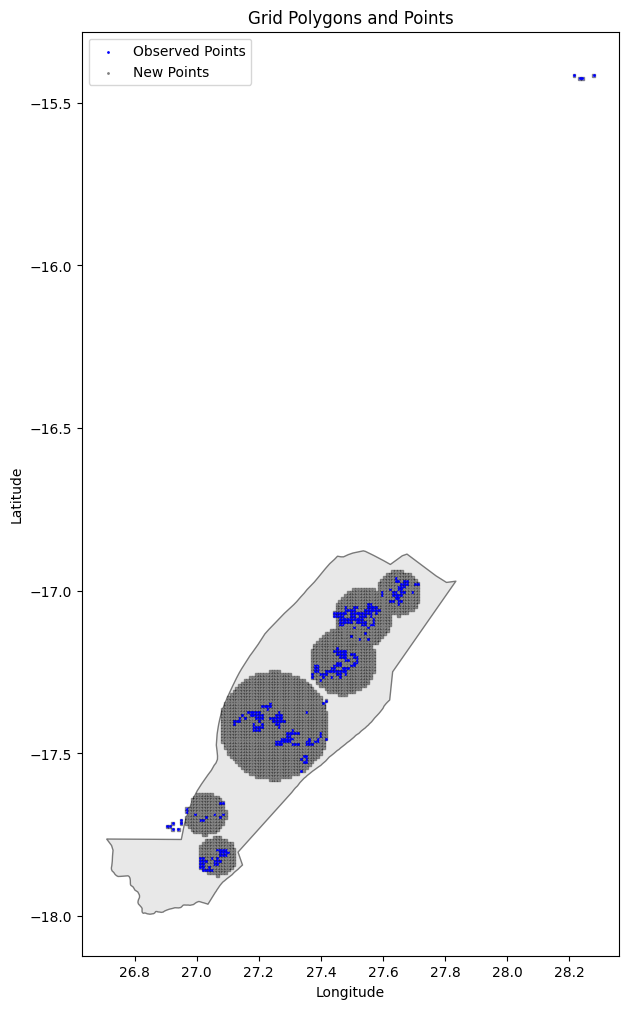

In [42]:
# Plot the boundary first
fig, ax = plt.subplots(figsize=(12, 12))
boundary_gdf.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)


# Observed grid points
observed_geom = gpd.GeoDataFrame(aggregated_df[aggregated_df['observed'] == True], geometry='geometry', crs="EPSG:4326")
new_geom =  gpd.GeoDataFrame(aggregated_df[aggregated_df['observed'] == False],  geometry='geometry', crs="EPSG:4326")

# Plot observed polygons (blue)
observed_geom.plot(ax=ax, color='blue', edgecolor='black', alpha=0.4, label='Observed Squares')

# Plot new polygons (red)
new_geom.plot(ax=ax, color='grey', edgecolor='black', alpha=0.4, label='New Squares')

# Plot observed points (centroids of polygons)
plt.scatter(
    observed_geom['longitude_snapped'], 
    observed_geom['latitude_snapped'], 
    color='blue', 
    label='Observed Points', 
    s=1
)

# Plot new points (centroids of polygons)
plt.scatter(
    new_geom['longitude_snapped'], 
    new_geom['latitude_snapped'], 
    color='grey', 
    label='New Points', 
    s=1
)

# Add legend and labels
plt.legend()
plt.title('Grid Polygons and Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()

In [564]:
aggregated_df

,latitude_snapped,longitude_snapped,total_children,mat_total,pat_total,both_total,atleast1_total,geometry,observed
0,-17.858426,27.003234,2.0,0.0,0.0,0.0,0.0,POLYGON ((26.994250808480057 -17.8674092705713...,True
1,-17.858426,27.021200,20.0,1.0,1.0,1.0,1.0,POLYGON ((27.01221703197988 -17.86740927057132...,True
2,-17.858426,27.039166,10.0,0.0,0.0,0.0,0.0,POLYGON ((27.0301832554797 -17.867409270571326...,True
3,-17.858426,27.057133,10.0,0.0,0.0,0.0,0.0,POLYGON ((27.048149478979518 -17.8674092705713...,True
4,-17.840460,27.021200,10.0,0.0,0.0,0.0,0.0,POLYGON ((27.01221703197988 -17.84944304707150...,True
...,...,...,...,...,...,...,...,...,...
590,-17.786561,27.111031,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.102048149478982 -17.7955443765720...,False
591,-17.768595,27.039166,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.0301832554797 -17.777578153072223...,False
592,-17.768595,27.057133,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.048149478979518 -17.7775781530722...,False
593,-17.768595,27.075099,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.06611570247934 -17.77757815307222...,False


In [ ]:
# Step 1: Determine min and max for latitude and longitude
lat_min, lat_max = aggregated_df['latitude_snapped'].min(), aggregated_df['latitude_snapped'].max()
lon_min, lon_max = aggregated_df['longitude_snapped'].min(), aggregated_df['longitude_snapped'].max()

def normalize(value, min_val, max_val):
    """Normalize a value to the range [0, 1]."""
    return (value - min_val) / (max_val - min_val)

def normalize_polygon(polygon, lat_min, lat_max, lon_min, lon_max):
    """Normalize the vertices of a polygon."""
    normalized_coords = [
        (
            normalize(point[0], lon_min, lon_max),  # Normalize longitude
            normalize(point[1], lat_min, lat_max)   # Normalize latitude
        )
        for point in polygon.exterior.coords
    ]
    return Polygon(normalized_coords)

# Step 2: Normalize the lat/lon values and polygon geometries
aggregated_df['lat_normalized'] = aggregated_df['latitude_snapped'].apply(lambda x: normalize(x, lat_min, lat_max))
aggregated_df['lon_normalized'] = aggregated_df['longitude_snapped'].apply(lambda x: normalize(x, lon_min, lon_max))

aggregated_df['geometry_normalized'] = aggregated_df['geometry'].apply(
    lambda poly: normalize_polygon(poly, lat_min, lat_max, lon_min, lon_max)
)

# Step 3: Check the resulting DataFrame
aggregated_df[['latitude_snapped', 'longitude_snapped', 'lat_normalized', 'lon_normalized', 'geometry', 'geometry_normalized']]


,latitude_snapped,longitude_snapped,lat_normalized,lon_normalized,geometry,geometry_normalized
0,-17.858426,27.003234,0.000000,0.065789,POLYGON ((26.994250808480057 -17.8674092705713...,POLYGON ((0.0592105263157902 -0.00367647058823...
1,-17.858426,27.021200,0.000000,0.078947,POLYGON ((27.01221703197988 -17.86740927057132...,POLYGON ((0.0723684210526339 -0.00367647058823...
2,-17.858426,27.039166,0.000000,0.092105,POLYGON ((27.0301832554797 -17.867409270571326...,POLYGON ((0.085526315789475 -0.003676470588235...
3,-17.858426,27.057133,0.000000,0.105263,POLYGON ((27.048149478979518 -17.8674092705713...,POLYGON ((0.0986842105263162 -0.00367647058823...
4,-17.840460,27.021200,0.007353,0.078947,POLYGON ((27.01221703197988 -17.84944304707150...,POLYGON ((0.0723684210526339 0.003676470588235...
...,...,...,...,...,...,...
590,-17.786561,27.111031,0.029412,0.144737,POLYGON ((27.102048149478982 -17.7955443765720...,POLYGON ((0.1381578947368447 0.025735294117648...
591,-17.768595,27.039166,0.036765,0.092105,POLYGON ((27.0301832554797 -17.777578153072223...,POLYGON ((0.085526315789475 0.0330882352941181...
592,-17.768595,27.057133,0.036765,0.105263,POLYGON ((27.048149478979518 -17.7775781530722...,POLYGON ((0.0986842105263162 0.033088235294118...
593,-17.768595,27.075099,0.036765,0.118421,POLYGON ((27.06611570247934 -17.77757815307222...,POLYGON ((0.1118421052631599 0.033088235294118...


In [ ]:
def reverse_normalize(value, min_val, max_val):
    """Reverse normalization from the range [0, 1] to original [min, max]."""
    return value * (max_val - min_val) + min_val

def reverse_normalize_polygon(polygon, lat_min, lat_max, lon_min, lon_max):
    """Reverse normalization for polygon vertices."""
    original_coords = [
        (
            reverse_normalize(point[0], lon_min, lon_max),  # Reverse normalize longitude
            reverse_normalize(point[1], lat_min, lat_max)   # Reverse normalize latitude
        )
        for point in polygon.exterior.coords
    ]
    return Polygon(original_coords)

# Step 2: Reverse the normalization for the lat/lon values and polygon geometries
aggregated_df['lat_original'] = aggregated_df['lat_normalized'].apply(lambda x: reverse_normalize(x, lat_min, lat_max))
aggregated_df['lon_original'] = aggregated_df['lon_normalized'].apply(lambda x: reverse_normalize(x, lon_min, lon_max))

aggregated_df['geometry_original'] = aggregated_df['geometry_normalized'].apply(
    lambda poly: reverse_normalize_polygon(poly, lat_min, lat_max, lon_min, lon_max)
)

aggregated_df

,latitude_snapped,longitude_snapped,total_children,mat_total,pat_total,both_total,atleast1_total,geometry,observed,lat_normalized,lon_normalized,geometry_normalized,lat_original,lon_original,geometry_original
0,-17.867409,27.016709,4.0,0.0,0.0,0.0,0.0,POLYGON ((27.009971254042405 -17.8741466043837...,True,0.005464,0.078431,POLYGON ((0.0735294117647088 0.002732240437159...,-17.867409,27.016709,POLYGON ((27.009971254042405 -17.8741466043837...
1,-17.853935,27.016709,5.0,0.0,0.0,0.0,0.0,POLYGON ((27.009971254042405 -17.8606719367588...,True,0.010929,0.078431,POLYGON ((0.0735294117647088 0.008196721311475...,-17.853935,27.016709,POLYGON ((27.009971254042405 -17.8606719367588...
2,-17.853935,27.030183,22.0,1.0,1.0,1.0,1.0,POLYGON ((27.023445921667268 -17.8606719367588...,True,0.010929,0.088235,POLYGON ((0.0833333333333342 0.008196721311475...,-17.853935,27.030183,POLYGON ((27.023445921667268 -17.8606719367588...
3,-17.853935,27.043658,1.0,0.0,0.0,0.0,0.0,POLYGON ((27.036920589292134 -17.8606719367588...,True,0.010929,0.098039,POLYGON ((0.0931372549019622 0.008196721311475...,-17.853935,27.043658,POLYGON ((27.036920589292134 -17.8606719367588...
4,-17.853935,27.057133,10.0,0.0,0.0,0.0,0.0,"POLYGON ((27.050395256917 -17.860671936758894,...",True,0.010929,0.107843,POLYGON ((0.1029411764705902 0.008196721311475...,-17.853935,27.057133,"POLYGON ((27.050395256917 -17.860671936758894,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,-17.773087,27.043658,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.036920589292134 -17.7798239310097...,False,0.043716,0.098039,POLYGON ((0.0931372549019622 0.040983606557377...,-17.773087,27.043658,POLYGON ((27.036920589292134 -17.7798239310097...
1067,-17.773087,27.057133,NaN,NaN,NaN,NaN,NaN,"POLYGON ((27.050395256917 -17.7798239310097, 2...",False,0.043716,0.107843,POLYGON ((0.1029411764705902 0.040983606557377...,-17.773087,27.057133,"POLYGON ((27.050395256917 -17.7798239310097, 2..."
1068,-17.773087,27.070607,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.063869924541866 -17.7798239310097...,False,0.043716,0.117647,POLYGON ((0.1127450980392182 0.040983606557377...,-17.773087,27.070607,POLYGON ((27.063869924541866 -17.7798239310097...
1069,-17.773087,27.084082,NaN,NaN,NaN,NaN,NaN,POLYGON ((27.077344592166728 -17.7798239310097...,False,0.043716,0.127451,POLYGON ((0.1225490196078436 0.040983606557377...,-17.773087,27.084082,POLYGON ((27.077344592166728 -17.7798239310097...


In [549]:
final_df = aggregated_df[['lat_normalized', 'lon_normalized', 'geometry_normalized', 
                          'total_children', 'mat_total', 'pat_total',
                          'both_total','atleast1_total', 'observed']]

In [550]:
final_df = final_df.rename(columns={"geometry_normalized":"geometry"})

In [551]:
final_df = final_df.rename(columns={"lat_normalized":"lat",
                                   "lon_normalized":"lon",
                                   "total_children": "childtotal",
                                   "mat_total": "maternal",
                                   "pat_total": "paternal",
                                   "both_total": "double",
                                   "atleast1_total": "any"})

In [552]:
# Step 6: Create a GeoDataFrame
final_gdf = gpd.GeoDataFrame(final_df, geometry='geometry')

In [553]:
final_gdf

,lat,lon,geometry,childtotal,maternal,paternal,double,any,observed
0,0.005464,0.078431,"POLYGON ((0.07353 0.00273, 0.08333 0.00273, 0....",4.0,0.0,0.0,0.0,0.0,True
1,0.010929,0.078431,"POLYGON ((0.07353 0.00820, 0.08333 0.00820, 0....",5.0,0.0,0.0,0.0,0.0,True
2,0.010929,0.088235,"POLYGON ((0.08333 0.00820, 0.09314 0.00820, 0....",22.0,1.0,1.0,1.0,1.0,True
3,0.010929,0.098039,"POLYGON ((0.09314 0.00820, 0.10294 0.00820, 0....",1.0,0.0,0.0,0.0,0.0,True
4,0.010929,0.107843,"POLYGON ((0.10294 0.00820, 0.11275 0.00820, 0....",10.0,0.0,0.0,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...
1066,0.043716,0.098039,"POLYGON ((0.09314 0.04098, 0.10294 0.04098, 0....",NaN,NaN,NaN,NaN,NaN,False
1067,0.043716,0.107843,"POLYGON ((0.10294 0.04098, 0.11275 0.04098, 0....",NaN,NaN,NaN,NaN,NaN,False
1068,0.043716,0.117647,"POLYGON ((0.11275 0.04098, 0.12255 0.04098, 0....",NaN,NaN,NaN,NaN,NaN,False
1069,0.043716,0.127451,"POLYGON ((0.12255 0.04098, 0.13235 0.04098, 0....",NaN,NaN,NaN,NaN,NaN,False


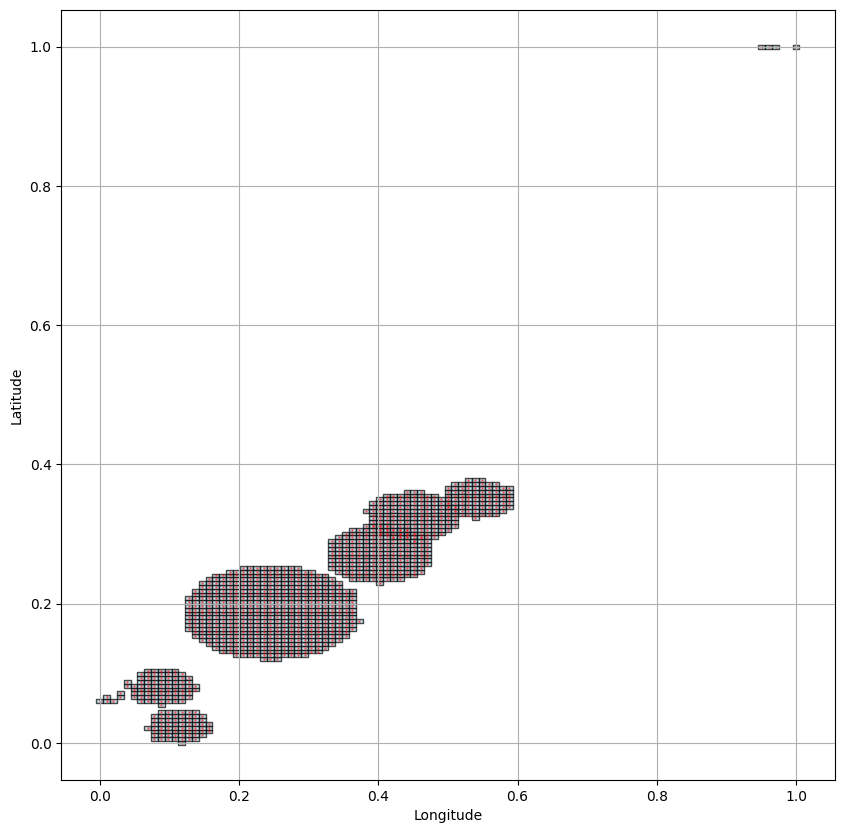

In [554]:
fig, ax = plt.subplots(figsize=(10, 10))


# Plot polygons
final_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7)


# Plot the centroids (original points)
gdf_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(aggregated_df['lon_normalized'], aggregated_df['lat_normalized']))
gdf_points.plot(ax=ax, color='red', markersize=1, alpha=0.4, label='Centroids')


# Final touches

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()

In [555]:
# Define the file paths
filepath = "sinazongwe_grids"
nested_directory = os.path.join(filepath, f'grid_{pixel_size_meters}m')

# Create the nested directories if they do not exist
try:
    os.makedirs(nested_directory, exist_ok=True)
    print(f"Nested directories '{nested_directory}' are ready.")
except Exception as e:
    print(f"Error creating directories '{nested_directory}': {e}")

# Define the file path for the shapefile and save it
shapefile_path = os.path.join(nested_directory, f"grid_{pixel_size_meters}m.shp")
final_gdf.to_file(shapefile_path, driver='ESRI Shapefile')
print(f"Shapefile saved to {shapefile_path}")

Nested directories 'sinazongwe_grids/grid_1500m' are ready.
Shapefile saved to sinazongwe_grids/grid_1500m/grid_1500m.shp


In [556]:
test_gdf = gpd.read_file(shapefile_path)
test_gdf

,lat,lon,childtotal,maternal,paternal,double,any,observed,geometry
0,0.005464,0.078431,4.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.07353 0.00273, 0.07353 0.00820, 0...."
1,0.010929,0.078431,5.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.07353 0.00820, 0.07353 0.01366, 0...."
2,0.010929,0.088235,22.0,1.0,1.0,1.0,1.0,1,"POLYGON ((0.08333 0.00820, 0.08333 0.01366, 0...."
3,0.010929,0.098039,1.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.09314 0.00820, 0.09314 0.01366, 0...."
4,0.010929,0.107843,10.0,0.0,0.0,0.0,0.0,1,"POLYGON ((0.10294 0.00820, 0.10294 0.01366, 0...."
...,...,...,...,...,...,...,...,...,...
1066,0.043716,0.098039,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.09314 0.04098, 0.09314 0.04645, 0...."
1067,0.043716,0.107843,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.10294 0.04098, 0.10294 0.04645, 0...."
1068,0.043716,0.117647,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.11275 0.04098, 0.11275 0.04645, 0...."
1069,0.043716,0.127451,NaN,NaN,NaN,NaN,NaN,0,"POLYGON ((0.12255 0.04098, 0.12255 0.04645, 0...."
